# TCMD-SS: HiRISE anomaly detection

Masked conditional diffusion for detecting structural image faults. All eight terrain classes are normal.

**V7 development AUROC: 0.7181. Final evaluation: pending.**

## Contents

1. Setup
2. Dataset and splits
3. Model
4. Training and reconstruction
5. Development anomalies
6. Anomaly scores
7. Calibration and inference
8. Results
9. Localization and failure cases
10. Checks and conclusions

Appendix: historical results, prevalence analysis and optional DINO code.

## 1. Setup

Attach the project folder, saved checkpoint and extracted HiRISE dataset. Enable a GPU in Kaggle or Colab and set the path overrides below if needed. The default mode uses saved results and runs a reconstruction demo. Training and full inference are optional.

In [1]:
from pathlib import Path
import sys, os, json, csv, math, random, statistics, hashlib, html, time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from IPython.display import display, HTML, SVG, Markdown, Image as DisplayImage

PROJECT_ROOT_OVERRIDE = None   # Example: Path('/content/TCMD-SS')
DATASET_ROOT_OVERRIDE = None   # Folder containing map-proj-v3_2/
INSTALL_DEPENDENCIES = False
RUN_TRAINING = False
RUN_DEVELOPMENT_INFERENCE = False
RUN_DINO = False
RUN_LIVE_RECONSTRUCTION = True
SEED = 42
print('Mode: review. Training, full development inference and DINO are opt-in.')

Mode: review. Training, full development inference and DINO are opt-in.


In [2]:
if INSTALL_DEPENDENCIES:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
        'torch', 'torchvision', 'numpy', 'pandas', 'Pillow', 'scikit-learn',
        'ImageHash', 'PyYAML', 'timm', 'safetensors', 'matplotlib', 'tqdm'])
else:
    print('Using the installed environment; no packages were changed.')

Using the installed environment; no packages were changed.


In [3]:
candidates = [Path.cwd(), *Path.cwd().parents]
for base in [Path('/content'), Path('/kaggle/working'), Path('/kaggle/input')]:
    if base.exists():
        candidates.extend([base, *[p for p in base.iterdir() if p.is_dir()]])
matches = list(dict.fromkeys(p.resolve() for p in candidates
    if (p/'outputs/dataset_audit.json').exists()
    and (p/'data/splits/generative/train_normal.csv').exists()))
if PROJECT_ROOT_OVERRIDE is not None:
    ROOT = Path(PROJECT_ROOT_OVERRIDE).resolve()
elif len(matches) == 1:
    ROOT = matches[0]
else:
    raise RuntimeError(f'Set PROJECT_ROOT_OVERRIDE. Evidence-folder candidates: {matches}')
assert (ROOT/'outputs/dataset_audit.json').exists(), 'Attach the project evidence folder.'
print('Selected project:', ROOT)

raw_candidates = [ROOT/'data/raw/hirise_v3_2']
if Path('/kaggle/input').exists():
    raw_candidates.extend(p.parent for p in Path('/kaggle/input').glob('**/map-proj-v3_2') if p.is_dir())
raw_candidates = list(dict.fromkeys(p.resolve() for p in raw_candidates if (p/'map-proj-v3_2').is_dir()))
if DATASET_ROOT_OVERRIDE is not None:
    DATA_ROOT = Path(DATASET_ROOT_OVERRIDE).resolve()
elif len(raw_candidates) == 1:
    DATA_ROOT = raw_candidates[0]
else:
    raise RuntimeError(f'Set DATASET_ROOT_OVERRIDE. HiRISE candidates: {raw_candidates}')
print('Dataset candidates:', raw_candidates)
print('Selected dataset:', DATA_ROOT)

Selected project: C:\Users\deves\OneDrive\Desktop\Projects\TCMD-SS
Dataset candidates: [WindowsPath('C:/Users/deves/OneDrive/Desktop/Projects/TCMD-SS/data/raw/hirise_v3_2')]
Selected dataset: C:\Users\deves\OneDrive\Desktop\Projects\TCMD-SS\data\raw\hirise_v3_2


In [4]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFilter, ImageDraw, ImageOps
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs): return iterable

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(4)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print({'python':sys.version.split()[0], 'torch':torch.__version__,
       'device':torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else 'CPU', 'seed':SEED})

C:\Users\deves\OneDrive\Desktop\Projects\TCMD-SS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'python': '3.14.3', 'torch': '2.11.0+cu128', 'device': 'NVIDIA GeForce RTX 3050 Laptop GPU', 'seed': 42}


In [5]:
SIZE = 128
CFG = dict(seed=SEED, size=SIZE, base_channels=32, batch_size=4, epochs=8,
           max_steps_per_epoch=128, learning_rate=3e-4, diffusion_steps=100,
           sampling_steps=15, reconstruction_seeds=(42,1042), top_fraction=.005,
           calibration_images=64, development_originals=16, severities=(.15,.30,.50))
RUN_DIR = (Path('/kaggle/working') if Path('/kaggle/working').exists() else ROOT/'outputs') / ('notebook_run_'+datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%f'))
print(json.dumps(CFG,indent=2))
print('Fresh outputs, only if enabled:', RUN_DIR)

{
  "seed": 42,
  "size": 128,
  "base_channels": 32,
  "batch_size": 4,
  "epochs": 8,
  "max_steps_per_epoch": 128,
  "learning_rate": 0.0003,
  "diffusion_steps": 100,
  "sampling_steps": 15,
  "reconstruction_seeds": [
    42,
    1042
  ],
  "top_fraction": 0.005,
  "calibration_images": 64,
  "development_originals": 16,
  "severities": [
    0.15,
    0.3,
    0.5
  ]
}
Fresh outputs, only if enabled: C:\Users\deves\OneDrive\Desktop\Projects\TCMD-SS\outputs\notebook_run_20260911T165855_124846


### Display helpers

In [6]:
def read_csv(path):
    with Path(path).open(newline='', encoding='utf-8-sig') as stream:
        return list(csv.DictReader(stream))

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def show_table(rows, columns=None, limit=20):
    rows=list(rows)
    if not rows:
        print('No rows.'); return
    columns=columns or list(rows[0])
    def value(x):
        return f'{x:.4f}' if isinstance(x,float) else str(x)
    header=''.join('<th style="padding:7px;text-align:left">'+html.escape(k)+'</th>' for k in columns)
    body=''.join('<tr>'+''.join('<td style="padding:7px;border-bottom:1px solid #ddd">'+html.escape(value(r.get(k,'')))+'</td>' for k in columns)+'</tr>' for r in rows[:limit])
    display(HTML('<table style="border-collapse:collapse"><thead style="background:#e9f1f7"><tr>'+header+'</tr></thead><tbody>'+body+'</tbody></table>'))
    if len(rows)>limit: print(f'Showing {limit} of {len(rows)} rows.')

def show_figure(relative_path):
    path=ROOT/relative_path
    if path.exists(): display(DisplayImage(filename=str(path)))
    else: print('Optional saved figure not attached:', relative_path)

def bars(labels, values, title, xlabel='Value'):
    labels=list(labels); values=list(map(float,values)); maximum=max(values,default=1) or 1
    height=65+32*len(labels)
    shapes=[f'<text x="12" y="24" font-size="17" font-weight="bold">{html.escape(title)}</text>']
    for i,(label,value) in enumerate(zip(labels,values)):
        y=43+i*32
        shapes += [f'<text x="10" y="{y+16}" font-size="12">{html.escape(str(label))}</text>',
                   f'<rect x="205" y="{y}" width="{440*value/maximum}" height="23" fill="#267b99"/>',
                   f'<text x="{213+440*value/maximum}" y="{y+16}" font-size="12">{value:.3f}</text>']
    shapes.append(f'<text x="205" y="{height-3}" font-size="11">{html.escape(xlabel)}; bars start at zero</text>')
    display(SVG(f'<svg xmlns="http://www.w3.org/2000/svg" width="760" height="{height}" style="background:white;font-family:sans-serif">'+''.join(shapes)+'</svg>'))

## 2. Dataset and splits

The dataset is NASA/JPL [HiRISE v3.2](https://zenodo.org/records/4002935). The following tables use the completed audit and download verification.

In [7]:
audit=read_json(ROOT/'outputs/dataset_audit.json')
download=read_json(ROOT/'outputs/download_verification.json')
show_table([{'item':key,'value':audit.get(key)} for key in
    ['image_count','base_landmark_count','source_observation_count','dimensions','channels','formats']])
display(download)

item,value
image_count,64947
base_landmark_count,10815
source_observation_count,232
dimensions,{'227x227': 64947}
channels,{'1': 64947}
formats,{'JPEG': 64947}


{'record': 'https://zenodo.org/records/4002935',
 'download_url': 'https://zenodo.org/records/4002935/files/hirise-map-proj-v3_2.zip?download=1',
 'archive': 'C:\\Users\\deves\\OneDrive\\Desktop\\Projects\\TCMD-SS\\data\\raw\\hirise-map-proj-v3_2.zip',
 'bytes': 911235740,
 'md5': '236d9c627db1a5970e77a01a8c8a035a',
 'md5_verified': True,
 'extracted_to': 'C:\\Users\\deves\\OneDrive\\Desktop\\Projects\\TCMD-SS\\data\\raw\\hirise_v3_2'}

In [8]:
print('Dataset root contents:')
for path in sorted(DATA_ROOT.iterdir()):
    print(('DIR ' if path.is_dir() else 'FILE'), path.name)
classes=read_csv(ROOT/'outputs/class_distribution.csv')
show_table(classes, ['class_id','class_name','image_count','original_image_count','augmented_image_count'])

Dataset root contents:
DIR  __MACOSX
FILE labels-map-proj_v3_2.txt
FILE labels-map-proj_v3_2_train_val_test.txt
FILE landmarks_map-proj-v3_2_classmap.csv
DIR  map-proj-v3_2


class_id,class_name,image_count,original_image_count,augmented_image_count
0,other,52722,8802,43920
1,crater,5024,794,4230
2,dark dune,766,166,600
3,slope streak,1575,267,1308
4,bright dune,1654,250,1404
5,impact ejecta,476,74,402
6,swiss cheese,1834,298,1536
7,spider,896,164,732


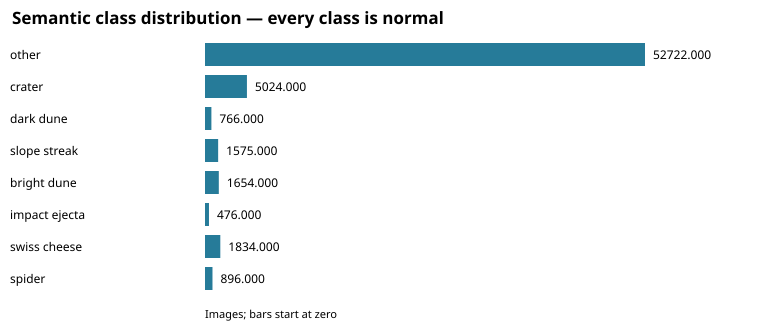

In [9]:
bars([r['class_name'] for r in classes], [r['image_count'] for r in classes],
     'Semantic class distribution — every class is normal', 'Images')

Class imbalance and repeated augmentations can bias sampling. Bounded experiments use originals, with source and duplicate-linked groups kept together.

### Augmentation and duplicate checks

Suffixes identify rotations (`r90`, `r180`, `r270`), flips (`fh`, `fv`) and brightness changes (`brt`). The parser illustrates this naming pattern; duplicate counts come from the full audit.

In [10]:
TRANSFORMS={'r90','r180','r270','fh','fv','brt'}
def base_identifier(filename):
    pieces=Path(filename).stem.lower().split('-')
    transformations=[]
    while len(pieces)>1 and pieces[-1] in TRANSFORMS:
        transformations.insert(0,pieces.pop())
    return '-'.join(pieces), transformations

for name in ['ESP_012373_0930_RED-0050.jpg','ESP_012373_0930_RED-0050-r90.jpg',
             'ESP_012373_0930_RED-0050-brt.jpg']:
    print(name,'->',base_identifier(name))
assert base_identifier('ESP_012373_0930_RED-0050-r90.jpg')[0] == base_identifier('ESP_012373_0930_RED-0050.jpg')[0]

ESP_012373_0930_RED-0050.jpg -> ('esp_012373_0930_red-0050', [])
ESP_012373_0930_RED-0050-r90.jpg -> ('esp_012373_0930_red-0050', ['r90'])
ESP_012373_0930_RED-0050-brt.jpg -> ('esp_012373_0930_red-0050', ['brt'])


In [11]:
def group_count(value):
    return len(value) if isinstance(value,(list,dict)) else value
show_table([{'check':k,'result':group_count(audit.get(k))} for k in
    ['augmentation_groups','exact_duplicate_groups','pixel_duplicate_groups','possible_leakage','unusual_files']])
print('Near-duplicate candidate counts:', audit.get('near_duplicate_pair_counts'))
print('Perceptual similarity is a candidate relationship, not proof of identical content.')

check,result
augmentation_groups,9022
exact_duplicate_groups,0
pixel_duplicate_groups,0
possible_leakage,6
unusual_files,0


Near-duplicate candidate counts: {'same_base': 8640, 'different_base': 142, 'cross_supplied_split_pairs': 24}
Perceptual similarity is a candidate relationship, not proof of identical content.


### Split checks

Training, calibration A, calibration B, development and final holdout are separated by source and linked image groups. Calibration A fits normalization; calibration B sets the threshold. Final images are not loaded.

In [12]:
GROUP_KEYS=('source_id','base_id','group_id','split_group_id')
def assert_group_separation(parts):
    for key in GROUP_KEYS:
        seen=set()
        for name,rows in parts.items():
            values={r[key] for r in rows}
            if not values or '' in values or seen & values:
                raise ValueError(f'Missing or overlapping {key} in {name}')
            seen.update(values)

names=['train_normal','calibration_a','calibration_b','development','final_holdout']
parts={name:read_csv(ROOT/f'data/splits/generative/{name}.csv') for name in names}
assert_group_separation(parts)
show_table([{'role':name,'images':len(rows),**{key:len({r[key] for r in rows}) for key in ['base_id','source_id']}} for name,rows in parts.items()])
print('All four grouping constraints pass.')

role,images,base_id,source_id
train_normal,39997,6829,158
calibration_a,1418,1418,22
calibration_b,959,959,19
development,1538,1538,30
final_holdout,71,71,3


All four grouping constraints pass.


In [13]:
exposed=read_csv(ROOT/'outputs/evaluation/predictions.csv')
exposed_sources={r['source_id'] for r in exposed}
final_sources={r['source_id'] for r in parts['final_holdout']}
assert not exposed_sources & final_sources
print('Previously evaluated source overlap with final reserve:',len(exposed_sources & final_sources))
print('Final reserve:',len(parts['final_holdout']),'originals from',len(final_sources),'sources')
print('This exposure check covers saved project history, not unknown external experiments.')

Previously evaluated source overlap with final reserve: 0
Final reserve: 71 originals from 3 sources
This exposure check covers saved project history, not unknown external experiments.


### Image loading and examples

Paths are resolved against the selected dataset folder. The loader checks the normal-only training labels.

In [14]:
def resolve_image(row):
    relative=Path(row['path'])
    path=(DATA_ROOT/relative).resolve()
    if not path.is_relative_to(DATA_ROOT.resolve()):
        raise ValueError('Manifest path escaped the dataset root')
    if not path.exists(): raise FileNotFoundError(path)
    return path

def assert_clean(rows):
    if not rows or any(float(r['is_anomaly'])!=0 or r['origin']!='hirise_clean'
                       or int(float(r['class_id'])) not in range(8) for r in rows):
        raise ValueError('Fitting/calibration requires clean HiRISE records')

def image_pixels(image):
    return image.get_flattened_data() if hasattr(image,'get_flattened_data') else image.getdata()

def tensor_image(image):
    values=image.convert('L')
    pixels=values.get_flattened_data() if hasattr(values,'get_flattened_data') else values.getdata()
    return torch.tensor(list(pixels),dtype=torch.float32).reshape(1,values.height,values.width)/255

def pil_image(values):
    values=values.detach().cpu().squeeze()
    return Image.frombytes('L',(values.shape[1],values.shape[0]),bytes(values.clamp(0,1).mul(255).round().to(torch.uint8).flatten().tolist()))

class MarsImages(Dataset):
    def __init__(self, rows, size=128):
        assert_clean(rows)
        self.rows,self.size=rows,size
    def __len__(self): return len(self.rows)
    def __getitem__(self,index):
        with Image.open(resolve_image(self.rows[index])) as source:
            return tensor_image(source.convert('L').resize((self.size,self.size),Image.Resampling.BILINEAR))

In [15]:
training_rows=read_csv(ROOT/'outputs/diffusion/training_manifest.csv')
validation_rows=read_csv(ROOT/'outputs/diffusion/validation_manifest.csv')
assert_clean(training_rows); assert_clean(validation_rows)
assert_group_separation({'fit':training_rows,'validation':validation_rows})
allowed={r['split_group_id'] for r in parts['train_normal']}
assert all(r['split_group_id'] in allowed for r in training_rows+validation_rows)
train_data=MarsImages(training_rows)
validation_data=MarsImages(validation_rows)
print('Actual historical fit/validation pools:',len(train_data),len(validation_data))
example_batch=torch.stack([train_data[i] for i in range(4)])
print('Batch:',tuple(example_batch.shape),'range:',float(example_batch.min()),float(example_batch.max()))

Actual historical fit/validation pools: 921 103
Batch: (4, 1, 128, 128) range: 0.0 0.9960784316062927


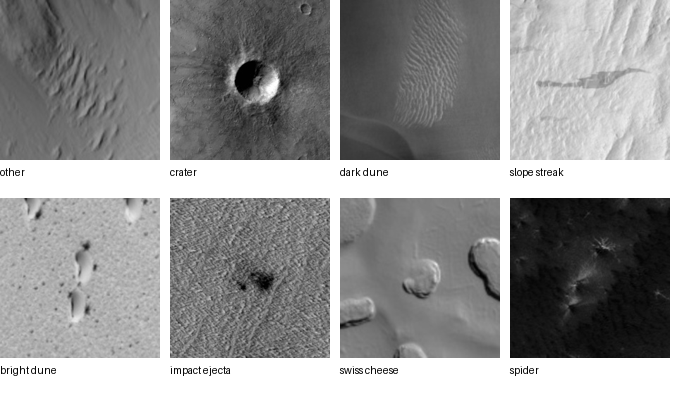

In [16]:
montage=Image.new('RGB',(4*170,2*198),'white')
draw=ImageDraw.Draw(montage)
for class_id in range(8):
    row=next(r for r in training_rows if int(float(r['class_id']))==class_id)
    with Image.open(resolve_image(row)) as source:
        tile=source.convert('RGB').resize((160,160))
    x=(class_id%4)*170; y=(class_id//4)*198
    montage.paste(tile,(x,y))
    draw.text((x,y+166),row['class_name'],fill='black')
display(montage)

filename,base_id,source_id
ESP_011283_2265_RED-0013-brt.jpg,esp_011283_2265_red-0013,esp_011283_2265
ESP_011283_2265_RED-0013-fh.jpg,esp_011283_2265_red-0013,esp_011283_2265
ESP_011283_2265_RED-0013-fv.jpg,esp_011283_2265_red-0013,esp_011283_2265
ESP_011283_2265_RED-0013-r180.jpg,esp_011283_2265_red-0013,esp_011283_2265
ESP_011283_2265_RED-0013-r270.jpg,esp_011283_2265_red-0013,esp_011283_2265
ESP_011283_2265_RED-0013-r90.jpg,esp_011283_2265_red-0013,esp_011283_2265
ESP_011283_2265_RED-0013.jpg,esp_011283_2265_red-0013,esp_011283_2265


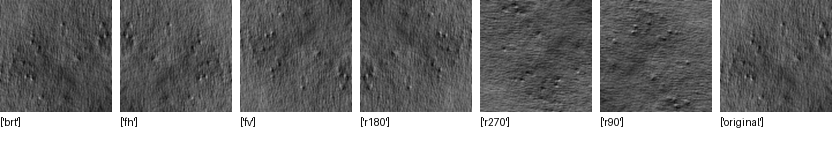

In [17]:
family_groups=defaultdict(list)
for row in parts['train_normal']: family_groups[row['base_id']].append(row)
example_family=next(rows for rows in family_groups.values() if len(rows)>=7)
show_table([{'filename':Path(r['path']).name,'base_id':r['base_id'],'source_id':r['source_id']} for r in example_family])
family_montage=Image.new('RGB',(7*120,145),'white'); draw=ImageDraw.Draw(family_montage)
for i,row in enumerate(sorted(example_family,key=lambda r:r['path'])[:7]):
    with Image.open(resolve_image(row)) as source: family_montage.paste(source.convert('RGB').resize((112,112)),(i*120,0))
    draw.text((i*120,116),str(base_identifier(row['path'])[1] or ['original']),fill='black')
display(family_montage)

## 3. Model

The U-Net receives noisy hidden pixels, visible context and a binary mask, and predicts diffusion noise. Group normalization supports small batches.

In [18]:
class Residual(nn.Module):
    def __init__(self, inputs: int, outputs: int, time_dim: int):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(8, inputs), inputs)
        self.conv1 = nn.Conv2d(inputs, outputs, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, outputs), outputs)
        self.conv2 = nn.Conv2d(outputs, outputs, 3, padding=1)
        self.time = nn.Linear(time_dim, outputs)
        self.skip = nn.Conv2d(inputs, outputs, 1) if inputs != outputs else nn.Identity()

    def forward(self, x, time):
        h = self.conv1(F.silu(self.norm1(x))) + self.time(time)[:, :, None, None]
        return self.skip(x) + self.conv2(F.silu(self.norm2(h)))

In [19]:
class MaskedUNet(nn.Module):
    def __init__(self, base: int = 64):
        super().__init__()
        self.base = base
        dim = base * 4
        self.time = nn.Sequential(nn.Linear(base, dim), nn.SiLU(), nn.Linear(dim, dim))
        self.input = nn.Conv2d(3, base, 3, padding=1)
        self.e1, self.e2 = Residual(base, base, dim), Residual(base, base*2, dim)
        self.mid = Residual(base*2, base*4, dim)
        self.d2, self.d1 = Residual(base*6, base*2, dim), Residual(base*3, base, dim)
        self.output = nn.Sequential(nn.GroupNorm(min(8, base), base), nn.SiLU(), nn.Conv2d(base, 1, 3, padding=1))

    def forward(self, noisy, visible, mask, timestep):
        frequency = torch.exp(-math.log(10000) * torch.arange(self.base//2, device=noisy.device) / max(1, self.base//2-1))
        phases = timestep[:, None].float() * frequency[None]
        embedding = self.time(torch.cat([phases.sin(), phases.cos()], dim=1))
        # The hidden query is never passed through the conditioning channel.
        x = self.input(torch.cat([noisy*mask + visible, visible, mask], dim=1))
        a = self.e1(x, embedding)
        b = self.e2(F.avg_pool2d(a, 2), embedding)
        c = self.mid(F.avg_pool2d(b, 2), embedding)
        d = self.d2(torch.cat([F.interpolate(c, size=b.shape[-2:], mode="nearest"), b], dim=1), embedding)
        return self.output(self.d1(torch.cat([F.interpolate(d, size=a.shape[-2:], mode="nearest"), a], dim=1), embedding))

In [20]:
model=MaskedUNet(CFG['base_channels']).to(DEVICE)
parameter_count=sum(p.numel() for p in model.parameters())
assert parameter_count==570497
print(model)
print(f'Trainable diffusion parameters: {parameter_count:,}')

MaskedUNet(
  (time): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (input): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (e1): Residual(
    (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time): Linear(in_features=128, out_features=32, bias=True)
    (skip): Identity()
  )
  (e2): Residual(
    (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time): Linear(in_features=128, out_features=64, bias=True)
    (skip): Conv2d(32, 6

### Masks and training objective

Training hides roughly 10–40% of an image using rectangles or irregular masks. Inference uses four complementary masks: every pixel is reconstructed while hidden once. The masked noise-prediction objective is

$$L=\frac{\sum M\,\lVert\epsilon_\theta(x_t,x\odot(1-M),M,t)-\epsilon\rVert^2}{\sum M}.$$

The original hidden pixels never enter the visible-context channel.

In [21]:
def training_masks(batch: int, size: int, device="cpu", generator=None) -> torch.Tensor:
    masks = []
    yy, xx = torch.meshgrid(torch.linspace(0, 1, size, device=device), torch.linspace(0, 1, size, device=device), indexing="ij")
    for _ in range(batch):
        fraction = float(torch.rand((), device=device, generator=generator)*0.3+0.1)
        kind = int(torch.randint(0, 3, (), device=device, generator=generator))
        if kind == 2:
            field = F.interpolate(torch.rand(1, 1, 8, 8, device=device, generator=generator), (size, size), mode="bicubic", align_corners=False)[0, 0]
        else:
            field = torch.full((size, size), -100., device=device)
            for _ in range(1 if kind == 0 else 3):
                center = torch.rand(2, device=device, generator=generator)
                aspect = float(torch.rand((), device=device, generator=generator)+0.5)
                distance = torch.maximum((yy-center[0]).abs()*aspect, (xx-center[1]).abs()/aspect)
                field = torch.maximum(field, -distance)
        mask = torch.zeros(size*size, device=device)
        mask[field.flatten().topk(max(1, int(fraction*size*size))).indices] = 1
        masks.append(mask.reshape(1, size, size))
    return torch.stack(masks)

In [22]:
def covering_masks(size: int, device="cpu") -> torch.Tensor:
    yy, xx = torch.meshgrid(torch.arange(size, device=device), torch.arange(size, device=device), indexing="ij")
    labels = ((yy // max(1, size//4)) % 2)*2 + (xx // max(1, size//4)) % 2
    return torch.stack([(labels == i).float()[None] for i in range(4)])

In [23]:
def schedule(steps: int, device="cpu") -> torch.Tensor:
    times = torch.linspace(0, steps, steps+1, device=device)/steps
    cumulative = torch.cos((times+0.008)/1.008 * math.pi/2).square()
    cumulative = cumulative / cumulative[0]
    betas = (1-cumulative[1:]/cumulative[:-1]).clamp(0.0001, 0.999)
    return torch.cumprod(1-betas, dim=0)

In [24]:
def denoising_loss(model, images, steps: int):
    x = images*2-1
    masks = training_masks(len(x), x.shape[-1], x.device)
    t = torch.randint(0, steps, (len(x),), device=x.device)
    alpha = schedule(steps, x.device)[t, None, None, None]
    noise = torch.randn_like(x)
    noisy = alpha.sqrt()*x+(1-alpha).sqrt()*noise
    prediction = model(noisy, x*(1-masks), masks, t)
    return ((prediction-noise).square()*masks).sum()/masks.sum().clamp_min(1)

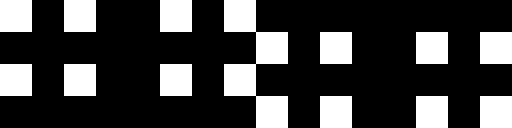

Four phases; hidden pixels per phase: [4096, 4096, 4096, 4096]
Every pixel hidden exactly once: True


In [25]:
masks=covering_masks(SIZE)
assert torch.equal(masks.sum(0),torch.ones(1,SIZE,SIZE))
mask_montage=Image.new('L',(SIZE*4,SIZE))
for i,mask in enumerate(masks): mask_montage.paste(pil_image(mask),(SIZE*i,0))
display(mask_montage)
print('Four phases; hidden pixels per phase:',[int(m.sum()) for m in masks])
print('Every pixel hidden exactly once:',bool((masks.sum(0)==1).all()))

In [26]:
# Gradient sanity check on normal training images; no optimizer step is taken.
random.seed(SEED); torch.manual_seed(SEED)
model.train(); model.zero_grad(set_to_none=True)
loss=denoising_loss(model,example_batch[:2].to(DEVICE),CFG['diffusion_steps'])
loss.backward()
assert torch.isfinite(loss)
assert all(torch.isfinite(p.grad).all() for p in model.parameters() if p.grad is not None)
print('Untrained-model masked loss (sanity check, not a training result):',float(loss.detach()))
model.zero_grad(set_to_none=True)

Untrained-model masked loss (sanity check, not a training result): 1.2364624738693237


### Reconstruction

Four complementary masks reconstruct every pixel while hidden. Two fixed noise seeds produce an average reconstruction and a disagreement map.

In [27]:
@torch.no_grad()
def reconstruct(model, images, steps: int = 100, sampling_steps: int = 8, seed: int = 42):
    model.eval()
    x = images*2-1
    alphas = schedule(steps, x.device)
    times = torch.linspace(steps-1, 0, sampling_steps, device=x.device).long().unique_consecutive()
    restored = torch.zeros_like(x)
    for index, hidden in enumerate(covering_masks(x.shape[-1], x.device)):
        mask = hidden[None].expand_as(x)
        visible = x*(1-mask)
        generator = torch.Generator(device=x.device).manual_seed(seed+index)
        # Shared image-independent noise makes scores independent of batch position.
        sample = torch.randn((1, 1, *x.shape[-2:]), generator=generator, device=x.device).expand_as(x).clone()
        for position, timestep in enumerate(times):
            t = timestep.expand(len(x))
            eps = model(sample, visible, mask, t)
            alpha = alphas[timestep]
            estimate = ((sample-(1-alpha).sqrt()*eps)/alpha.sqrt()).clamp(-1, 1)
            previous = alphas[times[position+1]] if position+1 < len(times) else torch.ones((), device=x.device)
            sample = previous.sqrt()*estimate+(1-previous).sqrt()*eps
        restored += estimate*mask
    restored = (restored+1)/2
    residual = (images-restored).abs()
    return restored, residual

In [28]:
@torch.no_grad()
def normal_reconstruction(model, images, diffusion_steps=100, sampling_steps=15,
                          seeds=(42, 1042)):
    if images.shape[-2:] != (128, 128):
        raise ValueError("This protocol requires 128x128 and 32x32 tiles")
    if len(seeds) != 2 or len(set(seeds)) != 2:
        raise ValueError("Two distinct deterministic seeds are required")
    if not 15 <= sampling_steps <= 30 or sampling_steps > diffusion_steps:
        raise ValueError("Use 15–30 DDIM steps within the diffusion schedule")
    samples = torch.stack([reconstruct(model, images, diffusion_steps, sampling_steps, s)[0]
                           for s in seeds])
    # Seed disagreement measures generative instability, not calibrated uncertainty.
    return samples.mean(0), samples.std(0, unbiased=False)

## 4. Training and reconstruction

The training loop uses the model and loss above and saves to a new folder. The historical checkpoint was trained with `scripts/train_diffusion.py`.

In [29]:
def train_normal_model(fit_rows, val_rows, config, destination, resume=None):
    assert_clean(fit_rows); assert_clean(val_rows)
    assert_group_separation({'fit':fit_rows,'validation':val_rows})
    destination=Path(destination)
    destination.mkdir(parents=True,exist_ok=False)
    random.seed(config['seed']); torch.manual_seed(config['seed'])
    network=MaskedUNet(config['base_channels']).to(DEVICE)
    optimizer=torch.optim.AdamW(network.parameters(),lr=config['learning_rate'])
    scaler=torch.amp.GradScaler('cuda',enabled=DEVICE.type=='cuda')
    fit_loader=DataLoader(MarsImages(fit_rows),batch_size=config['batch_size'],shuffle=True,num_workers=0)
    val_loader=DataLoader(MarsImages(val_rows[:8]),batch_size=config['batch_size'],num_workers=0)
    history=[]; first_epoch=0; best=float('inf'); stale=0
    if resume is not None:
        state=torch.load(resume,map_location=DEVICE,weights_only=False)
        if state['training_bases'] != [r['base_id'] for r in fit_rows]:
            raise ValueError('Resume training subset changed')
        for key in ['base_channels','diffusion_steps','size']:
            if state['config'][key]!=config[key]: raise ValueError(f'Resume mismatch: {key}')
        network.load_state_dict(state['model']);optimizer.load_state_dict(state['optimizer'])
        scaler.load_state_dict(state['scaler'])
        history=state['history'];first_epoch=state['epoch']+1;best=state['best']
        torch.set_rng_state(state['torch_rng'].cpu());random.setstate(state['python_rng'])
        if DEVICE.type=='cuda' and state.get('cuda_rng'):torch.cuda.set_rng_state_all(state['cuda_rng'])
    for epoch in range(first_epoch,config['epochs']):
        network.train(); losses=[]
        for step,images in enumerate(tqdm(fit_loader,desc=f'Epoch {epoch+1}')):
            if step>=config['max_steps_per_epoch']:break
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type,enabled=DEVICE.type=='cuda'):
                loss=denoising_loss(network,images.to(DEVICE),config['diffusion_steps'])
            scaler.scale(loss).backward();scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(network.parameters(),1.)
            scaler.step(optimizer);scaler.update();losses.append(float(loss.detach()))
        val_errors=[]
        for images in val_loader:
            _,residual=reconstruct(network,images.to(DEVICE),config['diffusion_steps'],8,config['seed'])
            val_errors.extend(residual.mean((1,2,3)).cpu().tolist())
        val_loss=statistics.mean(val_errors); improved=val_loss<best
        best=min(best,val_loss);stale=0 if improved else stale+1
        history.append({'epoch':epoch+1,'loss':statistics.mean(losses),'normal_validation_l1':val_loss})
        state={'model':network.state_dict(),'optimizer':optimizer.state_dict(),'scaler':scaler.state_dict(),
               'epoch':epoch,'best':best,'history':history,'config':config,
               'training_bases':[r['base_id'] for r in fit_rows],'torch_rng':torch.get_rng_state(),
               'python_rng':random.getstate(),'cuda_rng':torch.cuda.get_rng_state_all() if DEVICE.type=='cuda' else None}
        torch.save(state,destination/'last.pt')
        if improved:torch.save(state,destination/'best.pt')
        (destination/'history.json').write_text(json.dumps(history,indent=2))
        print(history[-1])
        if stale>=8:break
    return network,history

In [30]:
if RUN_TRAINING:
    trained_model,fresh_history=train_normal_model(training_rows,validation_rows,CFG,RUN_DIR/'training')
else:
    print('Fresh training skipped. The next table is the saved historical run, not this session.')

Fresh training skipped. The next table is the saved historical run, not this session.


### Training history and checkpoint

The saved run completed eight epochs. Its best checkpoint was selected on a small normal validation subset.

{'epochs_completed': 8,
 'training_images': 921,
 'validation_images': 103,
 'steps_completed': 1024,
 'optimizer_samples_processed': 4096,
 'validation_scored_images': 8,
 'best_normal_validation_l1': 0.10807835776358843,
 'device': 'cuda',
 'parameters': 570497,
 'session_seconds': 94.05554980000306,
 'resumed_from': None,
 'provisional': True}

epoch,steps,samples,loss,normal_validation_l1,session_seconds
1,128,512,0.1504086009663297,0.22607340849936008,15.893064600000798
2,128,512,0.06515746796503663,0.23666710034012794,27.289778500002285
3,128,512,0.04910625498450827,0.14667831361293793,38.737916800004314
4,128,512,0.04619646582432324,0.15838419646024704,49.88394420000259
5,128,512,0.04329048942599911,0.15835666004568338,60.957723100000294
6,128,512,0.034536755902081495,0.10807835776358843,71.99433250000584
7,128,512,0.038109803092083894,0.11689361836761236,83.0381555999993
8,128,512,0.03220041317035793,0.19115868397057056,93.96926620000158


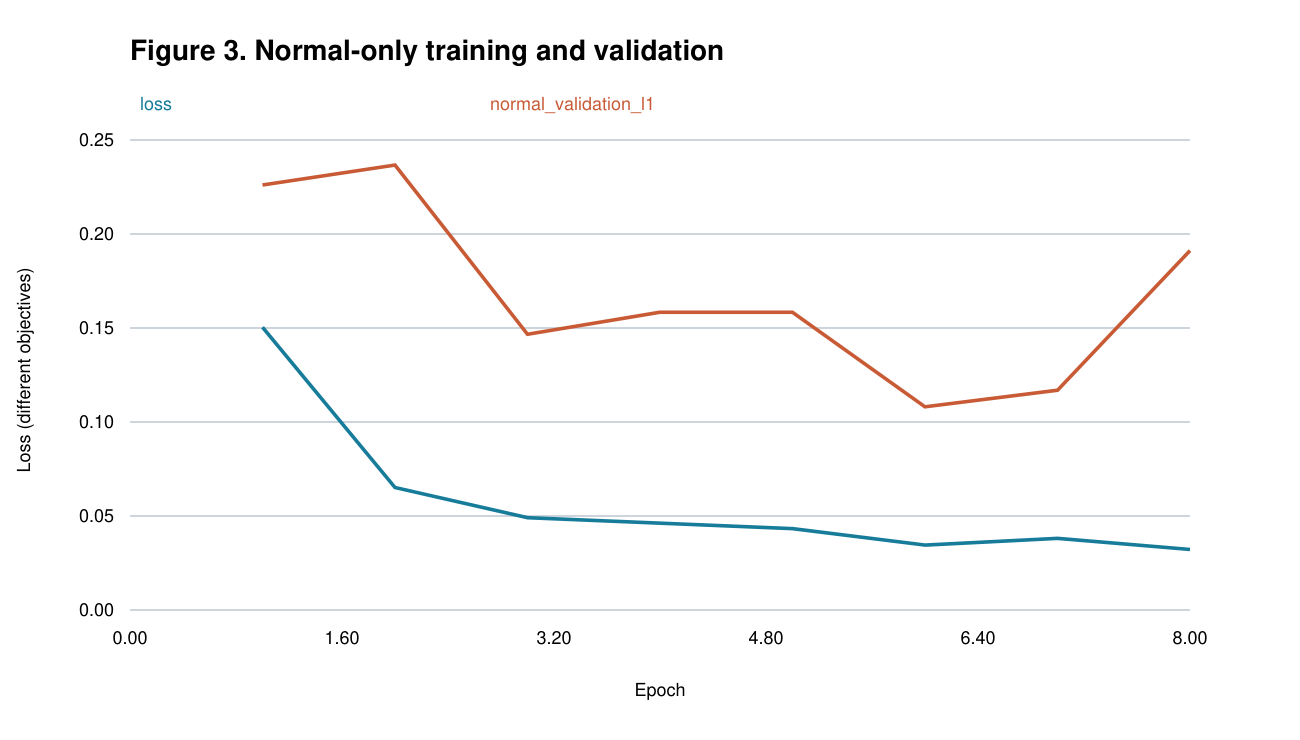

In [31]:
training_summary=read_json(ROOT/'outputs/diffusion/training_summary.json')
display(training_summary)
history=read_csv(ROOT/'outputs/diffusion/training_history.csv')
show_table(history)
show_figure('results/figures/training.png')

In [32]:
checkpoint_path=ROOT/'outputs/diffusion/checkpoints/best.pt'
if not checkpoint_path.exists():
    raise FileNotFoundError('Attach the existing trained project checkpoint to run reconstruction.')
checkpoint=torch.load(checkpoint_path,map_location='cpu',weights_only=False)
model.load_state_dict(checkpoint['model']);model.eval()
print('Loaded best checkpoint:',checkpoint_path.name)
print('SHA256:',hashlib.sha256(checkpoint_path.read_bytes()).hexdigest())

Loaded best checkpoint: best.pt
SHA256: 1ff8e253d1b808ca738b2870ba308c0a280e4b0850f7c539220a1fd4eda93c4e


Live normal-training-image reconstruction seconds: 0.8541787000012846
This is a reconstruction demonstration, not a new anomaly benchmark.


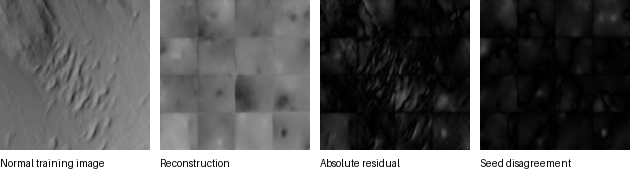

In [33]:
if RUN_LIVE_RECONSTRUCTION:
    demo_input=example_batch[:1].to(DEVICE)
    if DEVICE.type=='cuda':torch.cuda.synchronize()
    started=time.perf_counter()
    demo_generated,demo_uncertainty=normal_reconstruction(model,demo_input)
    if DEVICE.type=='cuda':torch.cuda.synchronize()
    print('Live normal-training-image reconstruction seconds:',time.perf_counter()-started)
    print('This is a reconstruction demonstration, not a new anomaly benchmark.')
    panel=Image.new('RGB',(4*160,190),'white');draw=ImageDraw.Draw(panel)
    for i,(label,value) in enumerate([('Normal training image',demo_input),('Reconstruction',demo_generated),
                                     ('Absolute residual',(demo_input-demo_generated).abs()),('Seed disagreement',demo_uncertainty)]):
        panel.paste(pil_image(value).resize((150,150)).convert('RGB'),(i*160,0));draw.text((i*160,157),label,fill='black')
    display(panel)
else:
    print('Live reconstruction skipped.')

## 5. Development anomalies

Six synthetic fault families use severities 0.15, 0.30 and 0.50. These images are excluded from generator training. Masks identify the modified regions; foreign content is generated procedurally.

In [34]:
FAMILIES=('stripes','dead_pixels','missing_patch','local_blur','patch_duplication','foreign_content')

In [35]:
def case_seed(base_id, family):
    return int(hashlib.sha256(f'42:{base_id}:{family}'.encode()).hexdigest()[:8],16)

In [36]:
def stress(image, family, severity, seed):
    if family not in FAMILIES or severity not in (.15,.30,.50):
        raise ValueError('This development protocol has six families and three fixed severities')
    rng=random.Random(seed)
    image=image.convert('L')
    w,h=image.size
    pixels=list(image_pixels(image)); result=pixels.copy(); mask=[0]*len(pixels)
    side=max(4,int(min(w,h)*(.08+.35*severity)))
    # Keep spatial seeds shared across severities so strength changes are easier to interpret.
    x=rng.randrange(max(1,w//2)); y=rng.randrange(max(1,h//2))
    if family=='stripes':
        horizontal=bool(seed%2);phase=rng.random()*2*math.pi
        for j in range(h):
            for i in range(w):
                k=j*w+i
                delta=255*.2*severity*math.sin(2*math.pi*(j if horizontal else i)/8+phase)
                result[k]=max(0,min(255,round(pixels[k]+delta))); mask[k]=255
    elif family=='dead_pixels':
        for k in range(len(pixels)):
            if rng.random()<.002+.02*severity:
                result[k]=255 if rng.randrange(2) else 0; mask[k]=255
    elif family=='local_blur':
        side=int(min(w,h)*(.25+.3*severity))
        blurred=list(image_pixels(image.filter(ImageFilter.GaussianBlur(.5+5*severity))))
        for j in range(y,min(h,y+side)):
            for i in range(x,min(w,x+side)):
                k=j*w+i;result[k]=blurred[k];mask[k]=255
    else:
        if family=='patch_duplication':
            # Copy between separated quadrants; overlapping source/target can create no-ops.
            x=w-side-2;y=h-side-2
        for j in range(side):
            for i in range(side):
                k=(y+j)*w+x+i
                if family=='missing_patch': value=0
                elif family=='patch_duplication': value=pixels[(2+j)*w+2+i]
                else:
                    pattern=255 if ((i//3+j//3)%2) else 0
                    alpha=.3+.7*severity;value=round(pixels[k]*(1-alpha)+pattern*alpha)
                result[k]=value;mask[k]=255
    changed=sum(a!=b for a,b in zip(pixels,result))
    if not changed:
        raise ValueError('Corruption made no visible change; retain as explicit benchmark failure')
    output=Image.frombytes('L',(w,h),bytes(result))
    return output, Image.frombytes('L',(w,h),bytes(mask))

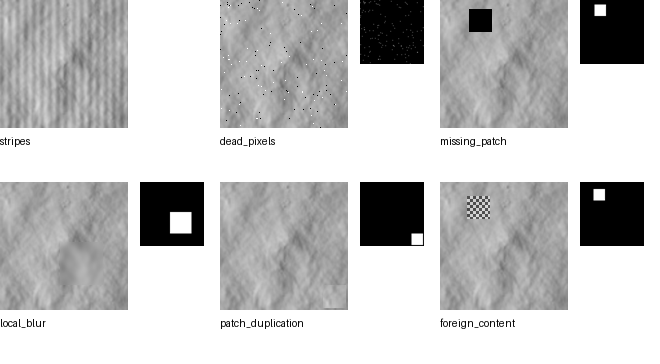

Left: corruption. Right: mask. Severity 0.30; development source only.


In [37]:
development_rows=read_csv(ROOT/'results/development/generative_v6/development_manifest.csv')
assert_clean(development_rows)
assert set(r['base_id'] for r in development_rows).issubset({r['base_id'] for r in exposed})
with Image.open(resolve_image(development_rows[0])) as source:
    normal_demo=source.convert('L').resize((SIZE,SIZE),Image.Resampling.BILINEAR)
panel=Image.new('RGB',(3*220,2*182),'white');draw=ImageDraw.Draw(panel)
for i,family in enumerate(FAMILIES):
    corrupted,mask=stress(normal_demo,family,.30,case_seed(development_rows[0]['base_id'],family))
    x=(i%3)*220;y=(i//3)*182
    panel.paste(corrupted.convert('RGB'),(x,y));panel.paste(mask.resize((64,64)).convert('RGB'),(x+140,y))
    draw.text((x,y+135),family,fill='black')
display(panel)
print('Left: corruption. Right: mask. Severity 0.30; development source only.')

## 6. Anomaly scores

Pixel residual, texture deficiency and directional spectral differences compare the observed image with its reconstruction.

In [38]:
def top_fraction(values: torch.Tensor, fraction: float = .005) -> torch.Tensor:
    if not 0 < fraction <= 1:
        raise ValueError("fraction must be in (0, 1]")
    flat = values.flatten(1)
    return flat.topk(max(1, math.ceil(flat.shape[1]*fraction)), dim=1).values.mean(1)

In [39]:
def local_energy(images):
    kernel = images.new_tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]])[None, None]
    laplacian = F.conv2d(F.pad(images, (1, 1, 1, 1), mode="reflect"), kernel)
    return F.avg_pool2d(laplacian.square(), 9, stride=1, padding=4)

In [40]:
def directional_features(images):
    profiles = torch.stack([images.mean(-1), images.mean(-2)], dim=2).squeeze(1)
    profiles = profiles-profiles.mean(-1, keepdim=True)
    window = torch.hann_window(profiles.shape[-1], device=images.device)
    # A tapered global profile emphasizes periodic scan artifacts without local FFT tiles.
    power = torch.fft.rfft(profiles*window, norm="ortho").abs().square()
    return torch.log1p(power[..., 1:]*100)

In [41]:
def score_maps(observed, generated, uncertainty):
    pixel=(observed-generated).abs()/(1+4*uncertainty)
    texture=(torch.log(local_energy(generated)+1e-4)-torch.log(local_energy(observed)+1e-4)).clamp_min(0)
    spectral=(directional_features(observed)-directional_features(generated)).abs()
    rows=(observed.mean(-1)-generated.mean(-1)).abs()[...,None]
    cols=(observed.mean(-2)-generated.mean(-2)).abs()[:,:,None,:]
    maps=torch.cat([pixel,texture,(rows+cols)/2],dim=1)
    scores=torch.stack([top_fraction(pixel),top_fraction(texture),top_fraction(spectral)],dim=1)
    return scores,maps

### V7 refinement

Local residual normalization reduces broad reconstruction mismatch. Narrow-band scoring emphasizes periodic artifacts, and a clean-data spread estimate handles zero MAD.

In [42]:
def frequency_peaks(images):
    profiles=torch.stack([images.mean(-1),images.mean(-2)],dim=2).squeeze(1)
    profiles=profiles-profiles.mean(-1,keepdim=True)
    power=torch.fft.rfft(profiles*torch.hann_window(128, device=images.device),norm='ortho').abs().square()
    # Nearby frequencies estimate broadband terrain energy; exclude the queried bin.
    background=(F.avg_pool1d(power,9,stride=1,padding=4)*9-power)/8
    return torch.log1p(power/(background+1e-4))[...,3:]

In [43]:
def robust_scale(values):
    median=torch.quantile(values,.5,dim=0)
    mad=1.4826*torch.quantile((values-median).abs(),.5,dim=0)
    # A spike at zero makes MAD degenerate; normal-only spread supplies a finite fallback.
    spread=(torch.quantile(values,.9,dim=0)-torch.quantile(values,.1,dim=0))/2.563
    return median,torch.where(mad>1e-6,mad,spread).clamp_min(1e-6)

In [44]:
def refined(item):
    x=item['input'][None];g=item['reconstruction'][None]
    residual=item['maps'][0:1][None]
    local=F.avg_pool2d(residual,15,stride=1,padding=7)
    # Suppress broad reconstruction mismatch while retaining isolated excess residual.
    pixel=(residual/(local+.03))[...,4:-4,4:-4]
    spectral=(frequency_peaks(x)-frequency_peaks(g)).clamp_min(0)
    texture=item['maps'][1][None,None,...]
    return torch.stack([top_fraction(pixel),top_fraction(texture),top_fraction(spectral)],dim=1)[0]

In [45]:
if RUN_LIVE_RECONSTRUCTION:
    demo_scores,demo_maps=score_maps(demo_input,demo_generated,demo_uncertainty)
    item={'input':demo_input[0].cpu(),'reconstruction':demo_generated[0].cpu(),'maps':demo_maps[0].cpu()}
    print('Initial pixel / texture / spectral raw scores:',demo_scores[0].cpu().tolist())
    print('Refined raw scores for the same normal demo:',refined(item).tolist())
    assert torch.isfinite(refined(item)).all()

Initial pixel / texture / spectral raw scores: [0.2549743056297302, 1.9236109256744385, 0.7097345590591431]
Refined raw scores for the same normal demo: [2.1282851696014404, 1.9236109256744385, 0.6800246834754944]


## 7. Calibration and inference

I fit a median and dispersion on calibration A, then compute the threshold from calibration B. A zero MAD is possible for one-sided texture maps; the normal 90th–10th percentile spread supplies a fallback. No anomalous scores determine the threshold.

$$z_j=(s_j-\operatorname{median}_A(s_j))/\operatorname{scale}_A(s_j),\qquad \tau=Q_{0.95}(S_B).$$

A 95th-percentile calibration threshold does not guarantee 5% false positives on new source observations.

In [46]:
def fit_clean_calibration(a_rows,a_scores,b_rows,b_scores,aggregation='mean'):
    assert_clean(a_rows);assert_clean(b_rows)
    assert_group_separation({'calibration_a':a_rows,'calibration_b':b_rows})
    median,scale=robust_scale(a_scores)
    z=(b_scores-median)/scale
    fused=z.mean(1) if aggregation=='mean' else z.max(1).values
    threshold=torch.quantile(fused,.95)
    return {'median':median,'scale':scale,'threshold':float(threshold),'aggregation':aggregation}

def calibrated_scores(scores,state):
    z=(scores-state['median'])/state['scale']
    return z.mean(1) if state['aggregation']=='mean' else z.max(1).values

In [47]:
v6=read_json(ROOT/'results/development/generative_v6/summary.json')
v7=read_json(ROOT/'results/development/generative_v7/summary.json')
show_table([{'role':'calibration A','images':v7['normal_calibration_a']},
            {'role':'calibration B','images':v7['normal_calibration_b']}])
print('Saved V7 median:',v7['median'])
print('Saved V7 scale:',v7['scale'])
print('Saved V7 mean-fusion threshold:',v7['best_diagnostic']['threshold'])

role,images
calibration A,64
calibration B,64


Saved V7 median: [1.992992639541626, 2.626230478286743, 0.6899925470352173]
Saved V7 scale: [0.48917216062545776, 1.5985060930252075, 0.4412727952003479]
Saved V7 mean-fusion threshold: 0.6986505389213562


### Development inference

Enable `RUN_DEVELOPMENT_INFERENCE` to score new development cases. The loop uses clean calibration A/B and writes predictions to a separate run folder.

In [48]:
@torch.no_grad()
def score_record(network,row,family='clean',severity=0.):
    with Image.open(resolve_image(row)) as source:
        image=source.convert('L').resize((SIZE,SIZE),Image.Resampling.BILINEAR)
    if family!='clean':image,_=stress(image,family,severity,case_seed(row['base_id'],family))
    x=tensor_image(image)[None].to(DEVICE)
    generated,uncertainty=normal_reconstruction(network,x)
    _,maps=score_maps(x,generated,uncertainty)
    return refined({'input':x[0].cpu(),'reconstruction':generated[0].cpu(),'maps':maps[0].cpu()})

def run_notebook_development(network,destination):
    a=read_csv(ROOT/'results/development/generative_v6/calibration_a_manifest.csv')
    b=read_csv(ROOT/'results/development/generative_v6/calibration_b_manifest.csv')
    dev=development_rows
    assert_group_separation({'a':a,'b':b,'development':dev,'final':parts['final_holdout']})
    destination=Path(destination);destination.mkdir(parents=True,exist_ok=False)
    def score_normals(rows,label):
        values=[]
        for i,row in enumerate(tqdm(rows,desc=label)):
            score=score_record(network,row);values.append(score)
            torch.save({'base_id':row['base_id'],'score':score},destination/f'{label}_{i}.pt')
        return torch.stack(values)
    a_scores=score_normals(a,'calibration_a');b_scores=score_normals(b,'calibration_b')
    state=fit_clean_calibration(a,a_scores,b,b_scores)
    torch.save(state,destination/'calibration.pt')
    predictions=[]
    for row in tqdm(dev,desc='Development originals'):
        cases=[('clean',0.)]+[(family,severity) for family in FAMILIES for severity in CFG['severities']]
        for family,severity in cases:
            raw=score_record(network,row,family,severity)
            value=float(calibrated_scores(raw[None],state)[0])
            predictions.append({'base_id':row['base_id'],'source_id':row['source_id'],'family':family,
                'severity':severity,'is_anomaly':int(family!='clean'),'score':value,'threshold':state['threshold']})
        # Persist each completed original so a failure does not erase completed work.
        (destination/'predictions.json').write_text(json.dumps(predictions,indent=2))
    return predictions,state

In [49]:
if RUN_DEVELOPMENT_INFERENCE:
    fresh_predictions,fresh_calibration=run_notebook_development(model,RUN_DIR/'development')
    print('Fresh development cases:',len(fresh_predictions))
else:
    print('Full development inference skipped. Reviewing the saved V6/V7 experiment below.')

Full development inference skipped. Reviewing the saved V6/V7 experiment below.


## 8. Results

AUROC measures ranking; recall and false-positive rate use the calibrated threshold. Average precision depends on anomaly prevalence. The following cells recompute metrics from saved predictions.

In [50]:
def quantile(values, fraction):
    values = sorted(values)
    index = (len(values)-1)*fraction
    lo, hi = math.floor(index), math.ceil(index)
    return values[lo]+(values[hi]-values[lo])*(index-lo)

In [51]:
def curves(labels, scores):
    positives, negatives = sum(labels), len(labels)-sum(labels)
    if not positives or not negatives:
        raise ValueError("Both classes are needed for ROC/PR")
    pairs = sorted(zip(scores, labels), reverse=True)
    result = [{"fpr":0., "tpr":0., "precision":1., "recall":0.}]
    tp = fp = index = 0
    while index < len(pairs):
        end = index
        while end < len(pairs) and pairs[end][0] == pairs[index][0]:
            tp += pairs[end][1]
            fp += 1-pairs[end][1]
            end += 1
        result.append({"fpr":fp/negatives, "tpr":tp/positives,
                       "precision":tp/(tp+fp), "recall":tp/positives})
        index = end
    return result

In [52]:
def metrics(rows, scores, threshold):
    labels = [int(float(r["is_anomaly"])) for r in rows]
    curve = curves(labels, scores)
    auc = sum((b["fpr"]-a["fpr"])*(b["tpr"]+a["tpr"])/2 for a,b in zip(curve,curve[1:]))
    ap = sum((b["recall"]-a["recall"])*b["precision"] for a,b in zip(curve,curve[1:]))
    tp=sum(y == 1 and s > threshold for y,s in zip(labels,scores))
    fp=sum(y == 0 and s > threshold for y,s in zip(labels,scores))
    positives=sum(labels); negatives=len(labels)-positives
    precision=tp/(tp+fp) if tp+fp else 0.
    recall=tp/positives
    clean = {r["base_id"]:s for r,s,y in zip(rows,scores,labels) if y == 0}
    paired=[s > clean[r["base_id"]] for r,s,y in zip(rows,scores,labels) if y and r["base_id"] in clean]
    return {"auroc":auc,"auprc":ap,"precision":precision,"recall":recall,
            "f1":2*precision*recall/(precision+recall) if precision+recall else 0.,
            "fpr":fp/negatives,"tpr":recall,"tp":tp,"fp":fp,"tn":negatives-fp,"fn":positives-tp,
            "median_anomaly_score":statistics.median(s for s,y in zip(scores,labels) if y),
            "paired_anomaly_gt_clean":sum(paired)/len(paired) if paired else None,
            "paired_n":len(paired),"n":len(rows),"threshold":threshold}

In [53]:
v7_predictions=[r for r in read_csv(ROOT/'results/development/generative_v7/predictions.csv') if r['variant']=='complete_three_mean']
v7_values=[float(r['score']) for r in v7_predictions]
v7_threshold=float(v7_predictions[0]['threshold'])
recomputed=metrics(v7_predictions,v7_values,v7_threshold)
for key in ['auroc','auprc','f1','precision','recall']:
    assert abs(recomputed[key]-v7['best_diagnostic'][key])<1e-10
show_table([{'metric':key,'value':recomputed[key]} for key in
            ['auroc','auprc','f1','precision','recall','fpr','paired_anomaly_gt_clean']])

metric,value
auroc,0.7181
auprc,0.9792
f1,0.6190
precision,0.9848
recall,0.4514
fpr,0.1250
paired_anomaly_gt_clean,0.7431


In [54]:
show_table([{'actual':'normal','predicted normal':recomputed['tn'],'predicted anomaly':recomputed['fp']},
            {'actual':'anomaly','predicted normal':recomputed['fn'],'predicted anomaly':recomputed['tp']}])
print('Only 16 clean development images: each false positive changes FPR by 6.25 percentage points.')

actual,predicted normal,predicted anomaly
normal,14,2
anomaly,158,130


Only 16 clean development images: each false positive changes FPR by 6.25 percentage points.


### V6 and V7 comparison

Both versions use the same development cases. The historical benchmark in the appendix uses different corruptions.

version,auroc,tpr,fpr,f1,paired_anomaly_gt_clean
V6 initial maximum,0.6291,0.1840,0.1875,0.3081,0.6632
V7 refined mean,0.7181,0.4514,0.1250,0.6190,0.7431


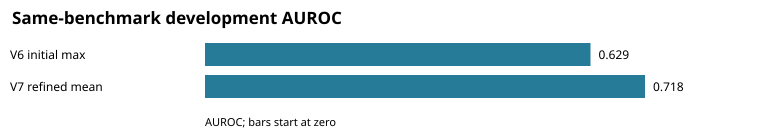

In [55]:
show_table([{'version':'V6 initial maximum',**v6['complete_three_max']},
            {'version':'V7 refined mean',**v7['best_diagnostic']}],
           ['version','auroc','tpr','fpr','f1','paired_anomaly_gt_clean'])
bars(['V6 initial max','V7 refined mean'],[v6['complete_three_max']['auroc'],v7['best_diagnostic']['auroc']],
     'Same-benchmark development AUROC','AUROC')

variant,auroc,tpr,fpr,f1
localized_pixel_mean,0.6145833333333334,0.2708333333333333,0.125,0.4239130434782608
texture_mean,0.5340711805555556,0.03125,0.0,0.06060606060606061
narrowband_spectral_mean,0.6108940972222222,0.2847222222222222,0.125,0.44086021505376344
pixel_spectral_mean,0.6916232638888888,0.4201388888888889,0.125,0.5888077858880778
pixel_spectral_max,0.6749131944444444,0.4201388888888889,0.125,0.5888077858880778
complete_three_mean,0.7180989583333334,0.4513888888888889,0.125,0.6190476190476191
complete_three_max,0.7098524305555556,0.4340277777777778,0.125,0.6024096385542169


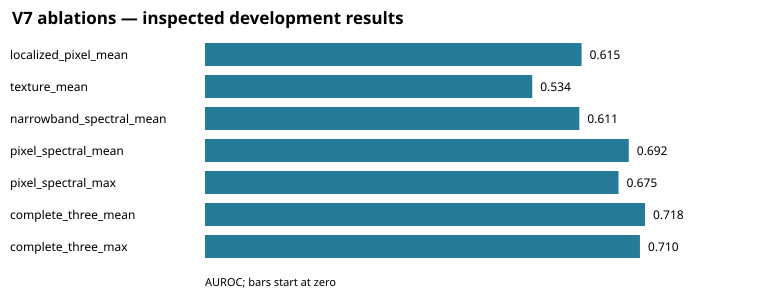

In [56]:
v7_ablations=read_csv(ROOT/'results/development/generative_v7/ablations.csv')
show_table(v7_ablations,['variant','auroc','tpr','fpr','f1'])
bars([r['variant'] for r in v7_ablations],[r['auroc'] for r in v7_ablations],
     'V7 ablations — inspected development results','AUROC')

### Results by fault and severity

Corruptions of the same original are dependent; 288 synthetic cases do not represent 288 independent sources.

value,auroc,tpr,median_anomaly_score,paired_anomaly_gt_clean
dead_pixels,0.99609375,1.0,2.3155384063720703,1.0
foreign_content,0.59375,0.1875,0.13201173394918442,0.7916666666666666
local_blur,0.5403645833333334,0.16666666666666666,0.0708555206656456,0.5833333333333334
missing_patch,0.7473958333333334,0.2708333333333333,0.5156159400939941,0.875
patch_duplication,0.4739583333333333,0.10416666666666667,-0.02623629290610552,0.20833333333333334
stripes,0.95703125,0.9791666666666666,1.0712864398956299,1.0


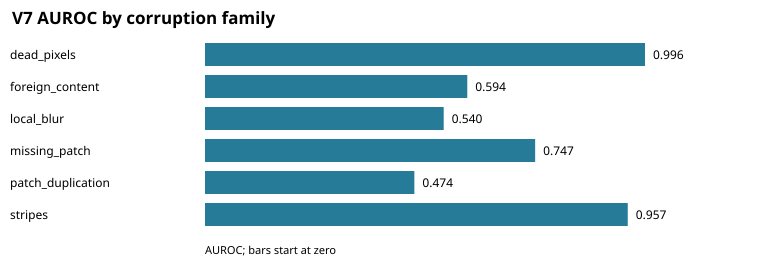

In [57]:
family_metrics=[r for r in read_csv(ROOT/'results/development/generative_v7/by_family_severity.csv')
                if r['variant']=='complete_three_mean' and r['dimension']=='family']
show_table(family_metrics,['value','auroc','tpr','median_anomaly_score','paired_anomaly_gt_clean'])
bars([r['value'] for r in family_metrics],[r['auroc'] for r in family_metrics],
     'V7 AUROC by corruption family','AUROC')

value,auroc,tpr,fpr,paired_anomaly_gt_clean
0.15,0.6907552083333334,0.4270833333333333,0.125,0.7083333333333334
0.3,0.7200520833333334,0.46875,0.125,0.7395833333333334
0.5,0.7434895833333334,0.4583333333333333,0.125,0.78125


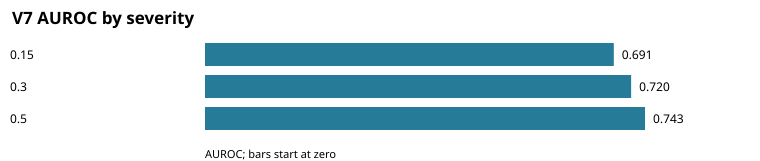

In [58]:
severity_metrics=[r for r in read_csv(ROOT/'results/development/generative_v7/by_family_severity.csv')
                  if r['variant']=='complete_three_mean' and r['dimension']=='severity']
show_table(severity_metrics,['value','auroc','tpr','fpr','paired_anomaly_gt_clean'])
bars([r['value'] for r in severity_metrics],[r['auroc'] for r in severity_metrics],
     'V7 AUROC by severity','AUROC')

## 9. Localization and failure cases

Pixel calibration is separate from image-score calibration. Spectral maps show row/column attribution, not inverse-FFT localization. Full-image stripe masks have no negative pixels, so their pixel AUROC is undefined.

In [59]:
def pixel_auc(mask,scores):
    mask=mask.flatten().long();scores=scores.flatten()
    positives=int(mask.sum());negatives=len(mask)-positives
    if not positives or not negatives:return None
    order=scores.argsort();values=scores[order];labels=mask[order]
    _,inverse,counts=torch.unique_consecutive(values,return_inverse=True,return_counts=True)
    positive_counts=torch.zeros(len(counts),dtype=torch.float64).scatter_add_(0,inverse,labels.double())
    negative_counts=counts.double()-positive_counts
    lower_negatives=negative_counts.cumsum(0)-negative_counts
    return float((positive_counts*(lower_negatives+.5*negative_counts)).sum()/(positives*negatives))

In [60]:
loc=read_json(ROOT/'results/development/generative_v7/localization_summary.json')
show_table(read_csv(ROOT/'results/development/generative_v7/localization_by_family.csv'),
           ['family','cases','pixel_auroc','iou_at_clean_pixel_q95','positive_map_inside_outside_ratio'])
display(loc['source_bootstrap'])
print('Bootstrap unit: source observation. This interval is conditional on development selection.')

family,cases,pixel_auroc,iou_at_clean_pixel_q95,positive_map_inside_outside_ratio
dead_pixels,48,0.8345670867262874,0.4462538951386879,9.57242332647244
foreign_content,48,0.5109897955007473,1.1834871361371587e-05,1.1060429985324542
local_blur,48,0.6772281661545795,0.05390880554756212,1.7746369286129873
missing_patch,48,0.7458075487105464,0.10367021723214483,2.8553214532633624
patch_duplication,48,0.5001123716282408,0.004751951937132844,0.9814717139427861
stripes,48,,0.05973943074544271,


{'variant': 'complete_three_mean',
 'sources': 12,
 'replicates': 200,
 'auroc_lower': 0.6868985902134773,
 'auroc_upper': 0.7650617283950618}

Bootstrap unit: source observation. This interval is conditional on development selection.


### Example predictions

Each example shows the input, reconstruction, uncertainty and discrepancy maps. Heatmaps have separate display scales. All examples below are saved severity-0.30 cases.

### Dead pixels —

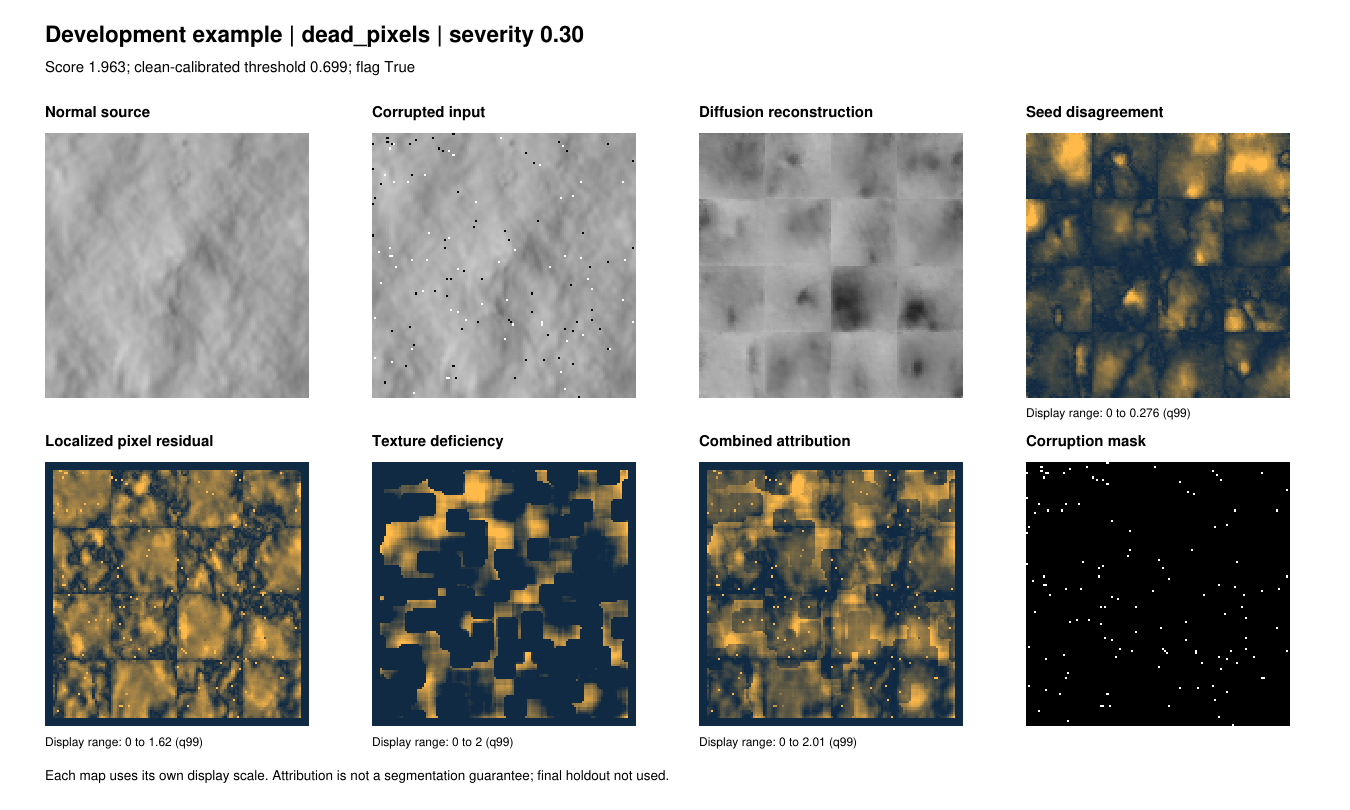

In [61]:
show_figure('results/figures/generative_v7/dead_pixels.png')

### Stripes —

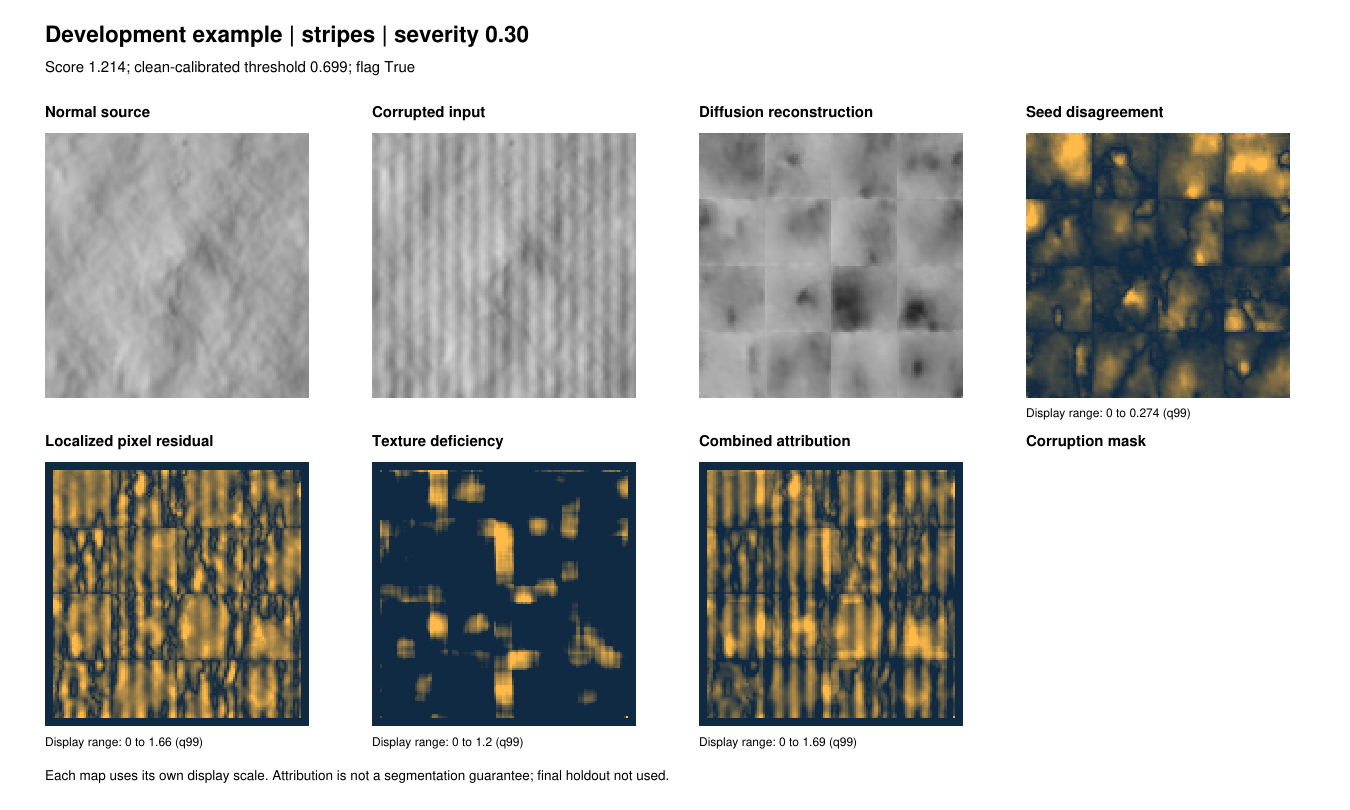

In [62]:
show_figure('results/figures/generative_v7/stripes.png')

### Missing patch —

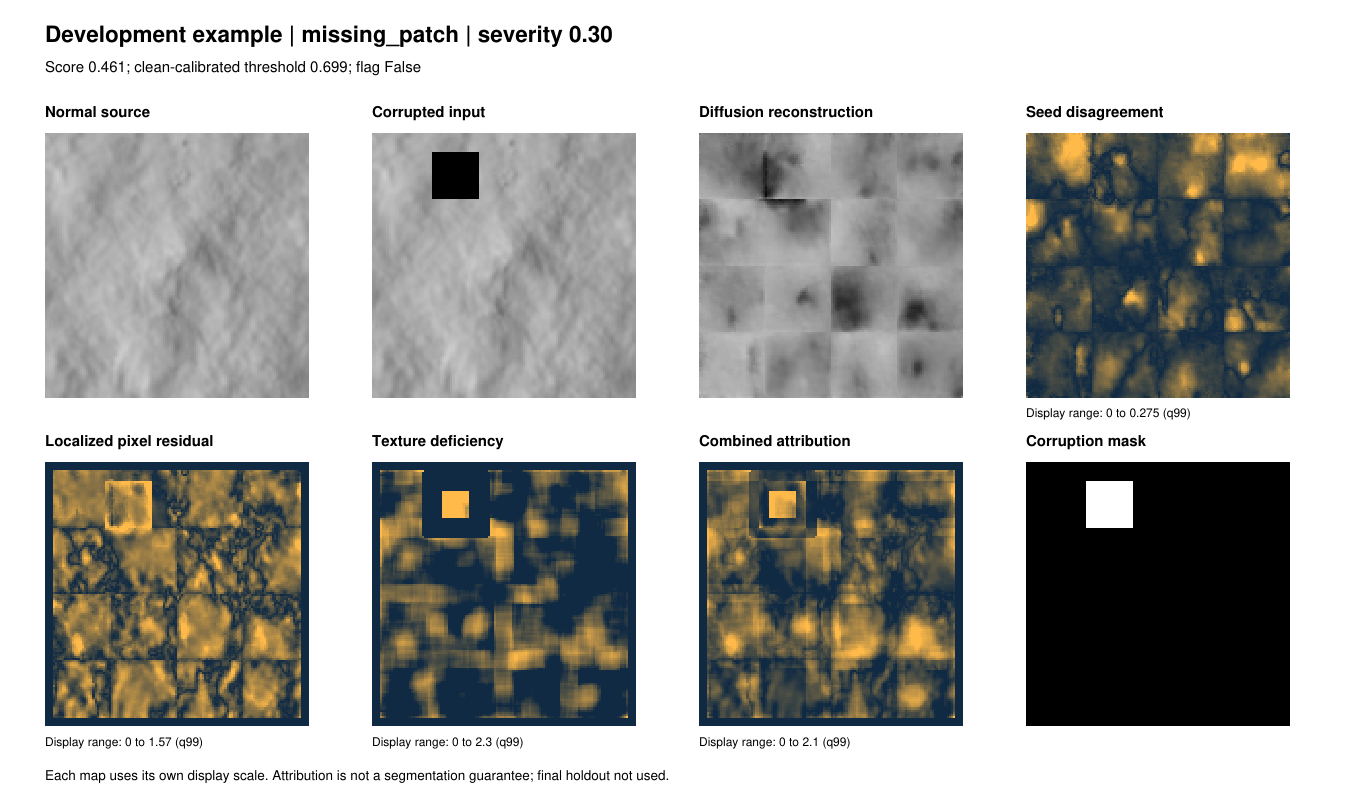

In [63]:
show_figure('results/figures/generative_v7/missing_patch.png')

### Local blur —

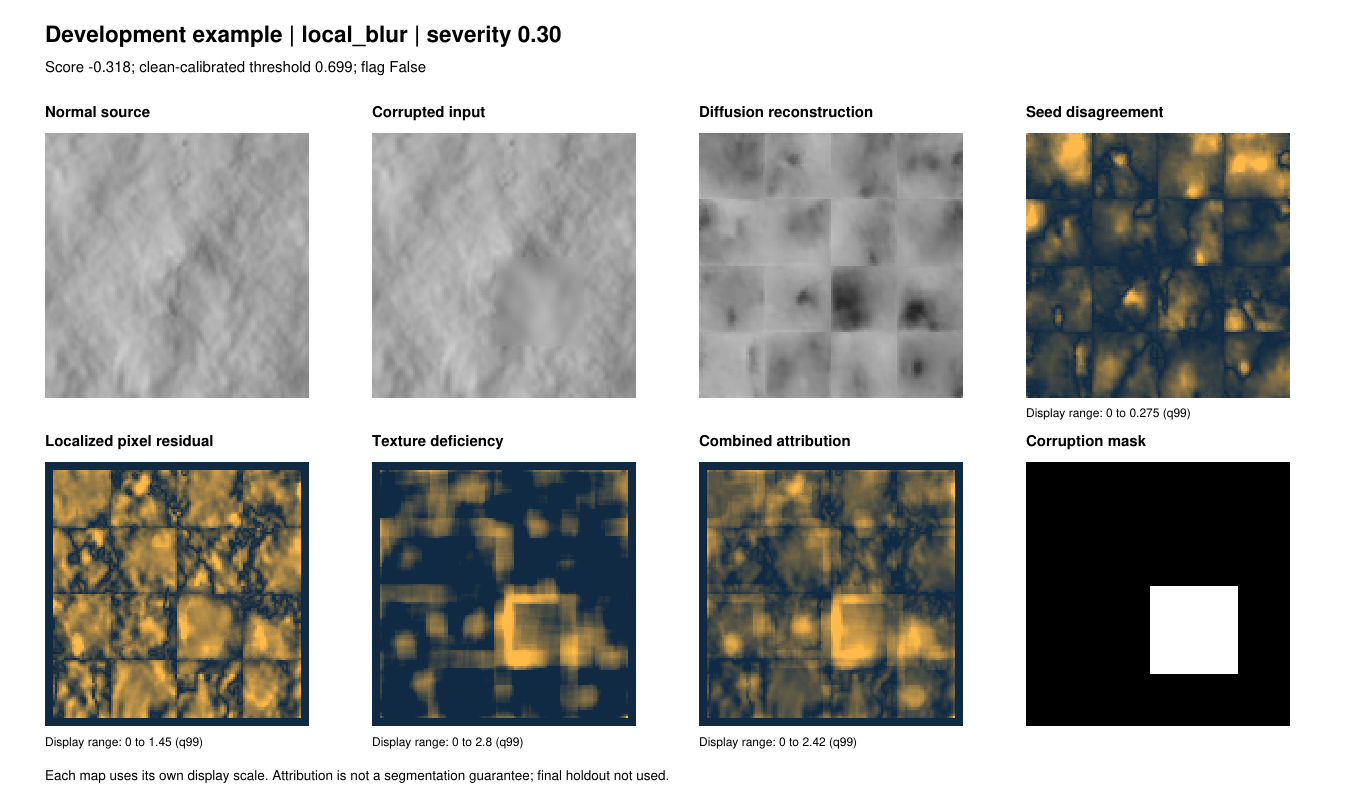

In [64]:
show_figure('results/figures/generative_v7/local_blur.png')

### Patch duplication —

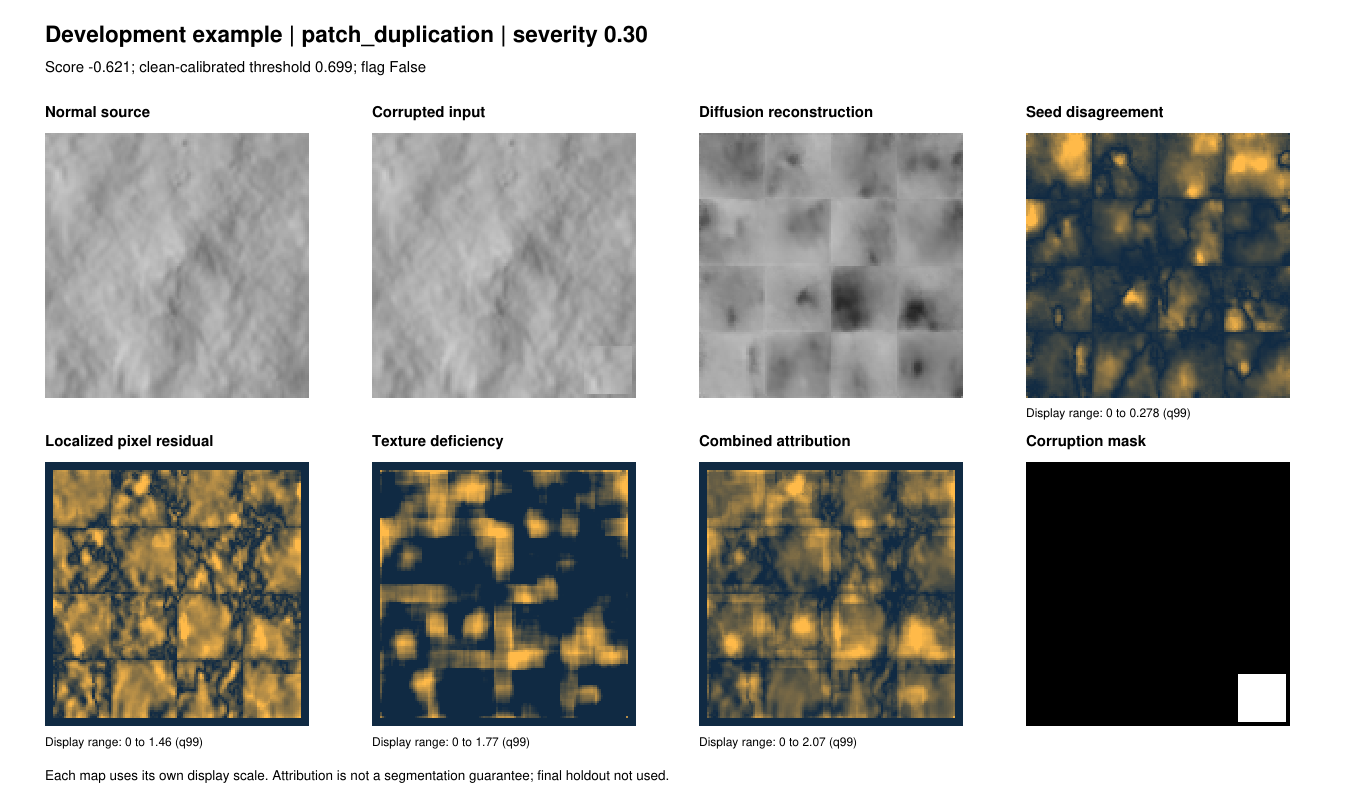

In [65]:
show_figure('results/figures/generative_v7/patch_duplication.png')

### Foreign content —

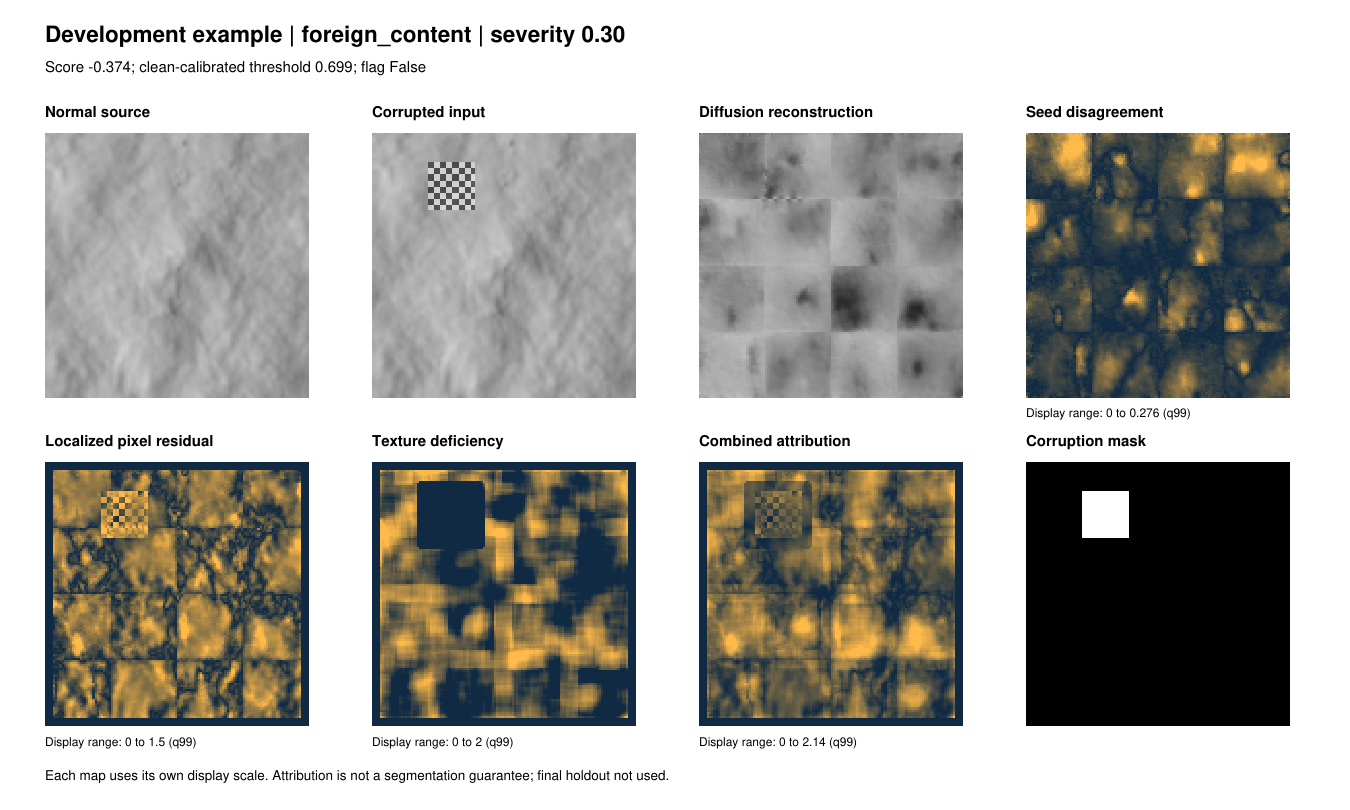

In [66]:
show_figure('results/figures/generative_v7/foreign_content.png')

In [67]:
false_positives=[r for r in v7_predictions if float(r['is_anomaly'])==0 and float(r['score'])>v7_threshold]
false_negatives=[r for r in v7_predictions if float(r['is_anomaly'])==1 and float(r['score'])<=v7_threshold]
print('False positives:')
show_table(false_positives,['base_id','source_id','score','threshold'])
print('Ten lowest-scoring missed corruptions:')
show_table(sorted(false_negatives,key=lambda r:float(r['score']))[:10],['base_id','family','severity','score','threshold'])

False positives:


base_id,source_id,score,threshold
psp_006766_1850_red-0037,psp_006766_1850,1.1497076749801636,0.6986505389213562
esp_016613_2570_red-0043,esp_016613_2570,0.7550728917121887,0.6986505389213562


Ten lowest-scoring missed corruptions:


base_id,family,severity,score,threshold
esp_013141_2105_red-0004,patch_duplication,0.15,-0.8994987607002258,0.6986505389213562
esp_013141_2105_red-0004,patch_duplication,0.3,-0.8732190132141113,0.6986505389213562
esp_013141_2105_red-0004,local_blur,0.15,-0.8371474742889404,0.6986505389213562
esp_013141_2105_red-0004,local_blur,0.3,-0.8359332084655762,0.6986505389213562
esp_013141_2105_red-0004,local_blur,0.5,-0.8344048857688904,0.6986505389213562
esp_013141_2105_red-0004,patch_duplication,0.5,-0.7481964230537415,0.6986505389213562
esp_013141_2105_red-0004,foreign_content,0.15,-0.6891219019889832,0.6986505389213562
esp_020133_1720_red-0022,patch_duplication,0.5,-0.632840633392334,0.6986505389213562
esp_020133_1720_red-0022,patch_duplication,0.3,-0.621272623538971,0.6986505389213562
esp_049651_1050_red-0070,patch_duplication,0.5,-0.6197710037231445,0.6986505389213562


## 10. Checks and conclusions

Check group separation, mask coverage, tied-score metrics, calibration spread and corruption reproducibility.

In [68]:
assert_group_separation(parts)
assert torch.equal(covering_masks(SIZE).sum(0),torch.ones(1,SIZE,SIZE))
assert pixel_auc(torch.tensor([0,1]),torch.tensor([1.,1.]))==.5
assert pixel_auc(torch.tensor([1,1]),torch.tensor([0.,1.])) is None
median,scale=robust_scale(torch.tensor([[0.],[0.],[0.],[0.],[1.],[2.]]))
assert float(scale)>.1
for family in FAMILIES:
    first,first_mask=stress(normal_demo,family,.30,42)
    second,second_mask=stress(normal_demo,family,.30,42)
    assert first.tobytes()==second.tobytes() and first_mask.tobytes()==second_mask.tobytes()
assert not (ROOT/'results/final/final_run_claim.json').exists()
print('Inline sanity checks passed; final evaluation has not been claimed.')

Inline sanity checks passed; final evaluation has not been claimed.


### Conclusions

V7 improves development AUROC to **0.7181**, with **45.14% recall** and **12.5% false positives**. Copy-move detection and foreign-content localization remain weak. More clean calibration and development validation are needed before freezing the model and evaluating the final holdout.

[Experiment history](../MODEL_EVOLUTION.md) · [HiRISE dataset](https://zenodo.org/records/4002935)

Saved results are retained in `outputs/` and `results/development/`. Optional fresh runs write to separate folders.

## Appendix A. Historical benchmark

This earlier study used 128 clean images and 1,056 different synthetic cases. Its equal-weight AUROC of 0.9011 is not directly comparable to V7.

variant,auroc,recall,false_positive_rate,f1
V1_diffusion,0.7323367956912878,0.3409090909090909,0.0625,0.5056179775280899
V2_diffusion_semantic,0.8206972064393939,0.5113636363636364,0.0546875,0.6737367436057392
V3_TCMD_SS,0.8893229166666666,0.6581439393939394,0.0546875,0.7906712172923777
without_semantic,0.8566080729166667,0.571969696969697,0.0703125,0.7237866986219293
without_spectral,0.8126923532196969,0.4981060606060606,0.0625,0.6616352201257861
without_latent,0.8915534741950757,0.6439393939393939,0.0703125,0.7793696275071633
equal_weight,0.9010786576704546,0.6458333333333334,0.0390625,0.7825588066551922


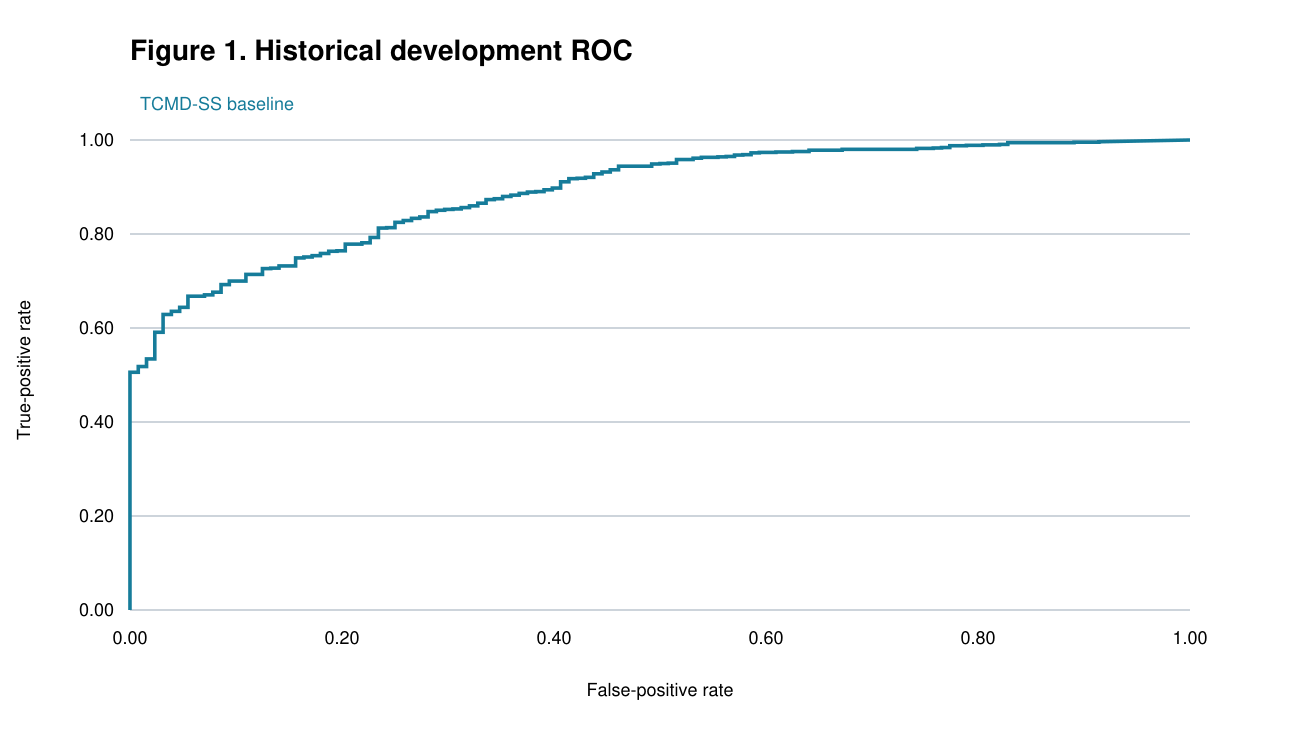

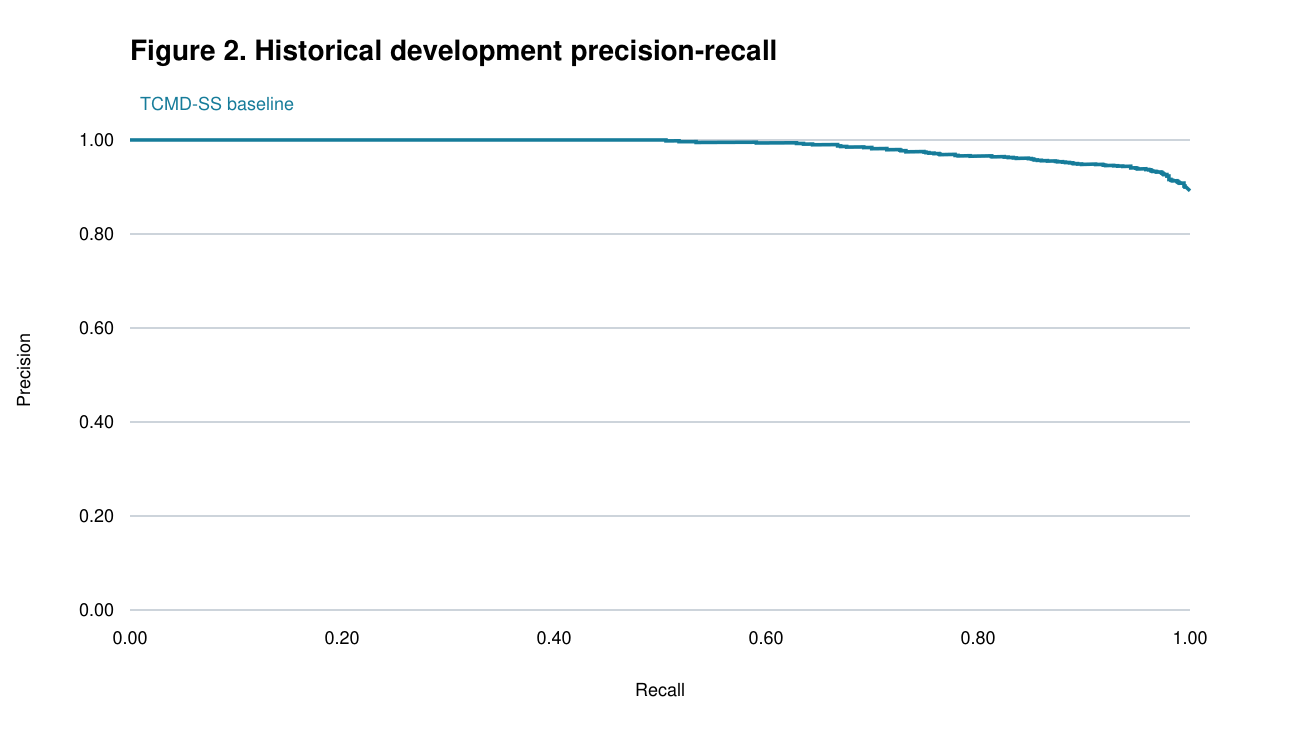

In [69]:
old_predictions=read_csv(ROOT/'outputs/evaluation/predictions.csv')
old_reference=read_json(ROOT/'outputs/evaluation/metrics.json')
old_metrics=metrics(old_predictions,[float(r['score']) for r in old_predictions],old_reference['threshold'])
assert abs(old_metrics['auroc']-old_reference['auroc'])<1e-12
show_table(read_csv(ROOT/'outputs/ablation_results.csv'),['variant','auroc','recall','false_positive_rate','f1'])
show_figure('results/figures/baseline_roc.png')
show_figure('results/figures/baseline_pr.png')

## Appendix B. Rare-anomaly sensitivity

Reweight the historical errors to a 5% anomaly prevalence. These are analytical estimates, not new deployment measurements. Related work: [VAD4Space](https://arxiv.org/abs/2603.13993).

In [70]:
def prevalence_metrics(labels,scores,threshold,prevalence):
    curve=curves(labels,scores)
    weighted_ap=0.
    for a,b in zip(curve,curve[1:]):
        denominator=prevalence*b['tpr']+(1-prevalence)*b['fpr']
        precision=prevalence*b['tpr']/denominator if denominator else 1.
        weighted_ap+=(b['recall']-a['recall'])*precision
    tp=sum(y==1 and s>threshold for y,s in zip(labels,scores))/sum(labels)
    fp=sum(y==0 and s>threshold for y,s in zip(labels,scores))/(len(labels)-sum(labels))
    denominator=prevalence*tp+(1-prevalence)*fp
    precision=prevalence*tp/denominator if denominator else 0.
    return {'assumed_anomaly_prevalence':prevalence,'tpr':tp,'fpr':fp,'expected_precision':precision,
            'reweighted_average_precision':weighted_ap,'expected_false_alerts_per_1000':1000*(1-prevalence)*fp,
            'expected_true_alerts_per_1000':1000*prevalence*tp}

In [71]:
rare_estimate=prevalence_metrics([int(float(r['is_anomaly'])) for r in old_predictions],
                               [float(r['score']) for r in old_predictions],old_reference['threshold'],.05)
display(rare_estimate)
show_table(read_csv(ROOT/'results/development/rare_prevalence/sensitivity.csv'),
           ['variant','assumed_anomaly_prevalence','expected_precision','expected_false_alerts_per_1000'])
print('Assumption: class-conditional score distributions remain unchanged as prevalence changes.')

{'assumed_anomaly_prevalence': 0.05,
 'tpr': 0.6581439393939394,
 'fpr': 0.0546875,
 'expected_precision': 0.3877807225554471,
 'reweighted_average_precision': 0.6430991536623931,
 'expected_false_alerts_per_1000': 51.953125,
 'expected_true_alerts_per_1000': 32.90719696969697}

variant,assumed_anomaly_prevalence,expected_precision,expected_false_alerts_per_1000
fixed_baseline,0.01,0.10838629186323055,54.140625
fixed_baseline,0.05,0.3877807225554471,51.953125
fixed_baseline,0.1,0.572134183988475,49.21875
historical_equal_weight,0.01,0.14310444316214657,38.671875
historical_equal_weight,0.05,0.46529080675422146,37.109375
historical_equal_weight,0.1,0.6475195822454308,35.15625


Assumption: class-conditional score distributions remain unchanged as prevalence changes.


## Appendix C. Optional DINO extension

Frozen DINOv2 compares corresponding patches in the observed and generated images. This extension is not part of the V7 results. `RUN_DINO=True` requires a working timm runtime and may download pretrained weights.

In [72]:
timm=None
load_file=None
if RUN_DINO:
    import timm
    from safetensors.torch import load_file
else:
    print('DINO skipped; V7 contains pixel, texture and directional spectral channels only.')

DINO skipped; V7 contains pixel, texture and directional spectral channels only.


In [73]:
class FrozenDINO(nn.Module):
    def __init__(self, name: str, weights: str | None = None):
        super().__init__()
        if "dino" not in name.lower():
            raise ValueError("A DINO backbone is required; random/other replacements are not allowed")
        self.name = name
        self.model = timm.create_model(name, pretrained=weights is None, num_classes=0)
        if weights:
            self.model.load_state_dict(load_file(str(ROOT / weights)), strict=True)
        self.model.eval().requires_grad_(False)
        cfg = self.model.pretrained_cfg
        self.register_buffer("mean", torch.tensor(cfg.get("mean", (0.485,0.456,0.406))).view(1,3,1,1))
        self.register_buffer("std", torch.tensor(cfg.get("std", (0.229,0.224,0.225))).view(1,3,1,1))
        self.size = cfg.get("input_size", (3,224,224))[-1]

    @torch.no_grad()
    def forward(self, images):
        self.model.eval()
        rgb = F.interpolate(images.repeat(1,3,1,1), (self.size,self.size), mode="bicubic", align_corners=False)
        tokens = self.model.forward_features((rgb-self.mean)/self.std)
        tokens = tokens[:, self.model.num_prefix_tokens:]
        side = math.isqrt(tokens.shape[1])
        if side*side != tokens.shape[1]:
            raise ValueError("Expected a square dense patch grid")
        return F.normalize(tokens.float(), dim=-1), side

In [74]:
def balanced_memory(tokens: torch.Tensor, maximum: int, seed: int = 42) -> torch.Tensor:
    if tokens.ndim != 3 or maximum < 5:
        raise ValueError("Memory needs B x patches x features and capacity >= k=5")
    generator = torch.Generator().manual_seed(seed)
    # Round-robin by base image gives each original equal opportunity under the cap.
    permutations = [torch.randperm(tokens.shape[1], generator=generator) for _ in range(len(tokens))]
    rows = []
    for j in range(tokens.shape[1]):
        for i in range(len(tokens)):
            if len(rows) < maximum:
                rows.append(tokens[i, permutations[i][j]])
        if len(rows) >= maximum:
            break
    return F.normalize(torch.stack(rows[:maximum]).float(), dim=-1)

In [75]:
def cosine_knn(query: torch.Tensor, memory: torch.Tensor, k: int = 5,
               query_chunk: int = 256, bank_chunk: int = 4096) -> torch.Tensor:
    flat = F.normalize(query.reshape(-1, query.shape[-1]), dim=-1)
    if len(memory) < k:
        raise ValueError("Normal memory is smaller than k")
    values = []
    for q in flat.split(query_chunk):
        best = torch.full((len(q), k), -float("inf"), device=q.device)
        for bank in memory.split(bank_chunk):
            similarity = q @ bank.to(q.device).T
            best = torch.cat([best, similarity], dim=1).topk(k, dim=1).values
        values.append((1-best.clamp(-1,1)).mean(dim=1))
    return torch.cat(values).reshape(query.shape[:-1])

In [76]:
def discrepancy_channels(observed, generated, uncertainty, observed_tokens, generated_tokens,
                         fraction=.005):
    if observed.shape != generated.shape or observed.shape != uncertainty.shape:
        raise ValueError("Image, reconstruction and uncertainty shapes must match")
    if observed_tokens.shape != generated_tokens.shape:
        raise ValueError("Corresponding DINO grids must match")
    pixel = (observed-generated).abs()/(1+uncertainty*4)
    # A one-sided ratio targets missing texture; clean-only calibration handles terrain variability.
    texture = (torch.log(local_energy(generated)+1e-4)-torch.log(local_energy(observed)+1e-4)).clamp_min(0)
    patch = (1-(F.normalize(observed_tokens, dim=-1)*F.normalize(generated_tokens, dim=-1)).sum(-1)).clamp_min(0)
    grid = math.isqrt(patch.shape[1])
    if grid*grid != patch.shape[1]:
        raise ValueError("DINO patch grid must be square")
    semantic = F.interpolate(patch[:, None].reshape(-1, 1, grid, grid), observed.shape[-2:], mode="bilinear", align_corners=False)
    spectral_difference = (directional_features(observed)-directional_features(generated)).abs()
    # Profile differences localize rows/columns; this is attribution, not frequency inversion.
    row = (observed.mean(-1)-generated.mean(-1)).abs()[..., None]
    column = (observed.mean(-2)-generated.mean(-2)).abs()[:, :, None, :]
    spectral_map = (row+column)/2
    scores = torch.stack([top_fraction(pixel, fraction), top_fraction(texture, fraction),
                          top_fraction(patch, fraction), top_fraction(spectral_difference, fraction)], 1)
    return scores, torch.cat([pixel, texture, semantic, spectral_map], 1)

In [77]:
if RUN_DINO:
    dino=FrozenDINO('vit_small_patch14_dinov2.lvd142m').to(DEVICE)
    if not RUN_LIVE_RECONSTRUCTION: raise RuntimeError('Enable live reconstruction for this comparison.')
    with torch.no_grad():
        observed_tokens,grid=dino(demo_input)
        generated_tokens,_=dino(demo_generated)
        four_scores,four_maps=discrepancy_channels(demo_input,demo_generated,demo_uncertainty,observed_tokens,generated_tokens)
    print('Patch grid:',grid,'token shape:',tuple(observed_tokens.shape))
    print('Uncalibrated four-channel normal-demo scores:',four_scores.cpu().tolist())
else:
    print('No DINO embeddings or scores were generated in this run.')

No DINO embeddings or scores were generated in this run.
